# Notebook to test quality control filters from cellprofiler features from a merged cell CSV aready created
Inputs Required
 - Database with cellprofiler outputs
   - Mainly use the Per_Cell table for per-cell features
     - Intensity
     - AreaShape features
     - Ratio of organelle area to total cell area
     - Texture features
     - Granularity features
     - Radial intensity distribution about nucleus
   - May additionally want to use mitochdondria or lysosomes.csv if analyzing these specifically 
 - Metadata CSV representing 96-well platemap
   - Long-form table containing passage number, staining conditons, treatments, etc
   - Produced automatically from an 8x12 table with the 96Well_PlateMap code
Outputs
- graphs for individual features
- clustering
## Set your paths here

In [22]:
# Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import sqlite3

# plotting
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns
import pingouin as pg
import re

from scipy import stats

from plate_information import *
from plate_preprocessing import *
from mitolyso_plot_functions import *

## Import the big csv

In [23]:
# import from a giant csv
# csvpath = "/Volumes/AllieS/Morphology_data/"
csvpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/postprocessed_csvs"

filename = "total_combined_cell.csv"
combined_cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))
display(combined_cell_df_mitolyso.shape)
# print(cell_df.shape, " ", filter_df.shape)

filename_borders_excluded = "total_combined_cell_borders_excluded.csv"


def fix_column_names(df):
    # remove "Cells_" from the beginning of column names
    df.columns = df.columns.str.replace(r"^Cell_", "", regex=True)
    # also rename nuclei cols in the filtered df when you made the df one-to-one
    df.columns = df.columns.str.replace(r"^Mean_Nuclei_", "Nuclei_", regex=True)
    df["Cell_Nuclei_Area_Ratio"] = df[
        "Nuclei_Area_Ratio"
    ]  # dupe column with the old name back
    unique_ID_df = df.reset_index().rename(
        columns={"index": "Cell_Unique_ID"}  # add a unique ID
    )
    return unique_ID_df


combined_cell_df_mitolyso = fix_column_names(combined_cell_df_mitolyso)

/tmp/ipykernel_2144/2089404407.py:6: DtypeWarning: Columns (1019,1020,1098,1099,1151,1152,1191,1192,3008) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))


(87682, 3015)

In [24]:
def normalize_intensity_to_well_average(df, intensity_cols, drop_well_avg_cols=False):
    # Create a new DataFrame to store the normalized values
    normalized_df = df.copy()

    # Group by 'Plate_Number' and 'Metadata_Well' to calculate the average intensity for each well
    well_averages = (
        df.groupby(["Plate_Number", "Metadata_Well"])[intensity_cols]
        .mean()
        .reset_index()
    )

    # Merge the well averages back to the original DataFrame
    normalized_df = normalized_df.merge(
        well_averages, on=["Plate_Number", "Metadata_Well"], suffixes=("", "_WellAvg")
    )

    # Normalize the intensity columns by dividing by the well average
    for col in intensity_cols:
        new_name = f"{col}_WellNormalized"
        normalized_df[new_name] = normalized_df[col] / normalized_df[f"{col}_WellAvg"]

    # Drop the well average columns
    if drop_well_avg_cols:
        normalized_df.drop(
            columns=[f"{col}_WellAvg" for col in intensity_cols], inplace=True
        )

    return normalized_df


def get_intensity_cols(df):
    intensity_cols = []
    for channel in ["DAPI", "LAMP1", "MitoTracker"]:
        channel=re.escape(channel)  # escape any special characters in the channel name
        if channel == "DAPI":
            pattern = rf"^(?=.*Nuclei_Intensity)(?=.*(?:MaxIntensity_{channel}|MeanIntensity_{channel}|MinIntensity_{channel}|MedianIntensity_{channel}))(?=.*_MAX)"
        else:
            pattern = rf"^Intensity_(?=.*(?:MaxIntensity_{channel}|MeanIntensity_{channel}|MinIntensity_{channel}|MedianIntensity_{channel}))(?=.*_MAX)"
        intensity_cols +=[
            col
            for col in df.columns
            # regex to match columns that contain our desired intensity cols
            if re.search(pattern,col)]
    return intensity_cols
intensity_cols = get_intensity_cols(combined_cell_df_mitolyso)
print("Intensity columns:", intensity_cols)
well_avg_cols = [f"{col}_WellAvg" for col in intensity_cols]
norm_intensity_cols = [f"{col}_WellNormalized" for col in intensity_cols]

combined_cell_df_mitolyso_test = normalize_intensity_to_well_average(
    combined_cell_df_mitolyso.copy(), intensity_cols
)
print("Intensity columns:", intensity_cols)
display(
    combined_cell_df_mitolyso_test[
        ["AllGroups", "Plate_Number", "Metadata_Well"]
        + intensity_cols
        + well_avg_cols
        + norm_intensity_cols
    ].head(20)
)

combined_cell_df_mitolyso = normalize_intensity_to_well_average(
    combined_cell_df_mitolyso, intensity_cols
)

Intensity columns: ['Nuclei_Intensity_MaxIntensity_DAPI_MAX', 'Nuclei_Intensity_MeanIntensity_DAPI_MAX', 'Nuclei_Intensity_MedianIntensity_DAPI_MAX', 'Nuclei_Intensity_MinIntensity_DAPI_MAX', 'Intensity_MaxIntensity_LAMP1_MAX', 'Intensity_MeanIntensity_LAMP1_MAX', 'Intensity_MedianIntensity_LAMP1_MAX', 'Intensity_MinIntensity_LAMP1_MAX', 'Intensity_MaxIntensity_MitoTracker_MAX', 'Intensity_MeanIntensity_MitoTracker_MAX', 'Intensity_MedianIntensity_MitoTracker_MAX', 'Intensity_MinIntensity_MitoTracker_MAX']
Intensity columns: ['Nuclei_Intensity_MaxIntensity_DAPI_MAX', 'Nuclei_Intensity_MeanIntensity_DAPI_MAX', 'Nuclei_Intensity_MedianIntensity_DAPI_MAX', 'Nuclei_Intensity_MinIntensity_DAPI_MAX', 'Intensity_MaxIntensity_LAMP1_MAX', 'Intensity_MeanIntensity_LAMP1_MAX', 'Intensity_MedianIntensity_LAMP1_MAX', 'Intensity_MinIntensity_LAMP1_MAX', 'Intensity_MaxIntensity_MitoTracker_MAX', 'Intensity_MeanIntensity_MitoTracker_MAX', 'Intensity_MedianIntensity_MitoTracker_MAX', 'Intensity_MinInte

,AllGroups,Plate_Number,Metadata_Well,Nuclei_Intensity_MaxIntensity_DAPI_MAX,Nuclei_Intensity_MeanIntensity_DAPI_MAX,Nuclei_Intensity_MedianIntensity_DAPI_MAX,Nuclei_Intensity_MinIntensity_DAPI_MAX,Intensity_MaxIntensity_LAMP1_MAX,Intensity_MeanIntensity_LAMP1_MAX,Intensity_MedianIntensity_LAMP1_MAX,...,Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized,Nuclei_Intensity_MinIntensity_DAPI_MAX_WellNormalized,Intensity_MaxIntensity_LAMP1_MAX_WellNormalized,Intensity_MeanIntensity_LAMP1_MAX_WellNormalized,Intensity_MedianIntensity_LAMP1_MAX_WellNormalized,Intensity_MinIntensity_LAMP1_MAX_WellNormalized,Intensity_MaxIntensity_MitoTracker_MAX_WellNormalized,Intensity_MeanIntensity_MitoTracker_MAX_WellNormalized,Intensity_MedianIntensity_MitoTracker_MAX_WellNormalized,Intensity_MinIntensity_MitoTracker_MAX_WellNormalized
0,Doxo,6.0,A02,0.204486,0.041611,0.028519,0.006104,0.176089,0.022776,0.015106,...,0.751561,0.938404,1.417755,1.692728,1.876777,1.001091,1.128927,0.931614,0.945760,0.877750
1,Doxo,6.0,A02,0.207279,0.048724,0.031083,0.004456,0.200031,0.026528,0.015290,...,0.819117,0.685035,1.610516,1.971589,1.899526,1.063660,1.420950,1.028550,1.174185,0.731458
2,Doxo,6.0,A02,0.181369,0.033043,0.026886,0.003891,0.163668,0.018597,0.008377,...,0.708534,0.598232,1.317751,1.382187,1.040758,0.922881,1.043736,0.790153,0.729357,0.692447
3,Doxo,6.0,A02,0.209659,0.042705,0.028153,0.004318,0.173968,0.023050,0.011124,...,0.741910,0.663921,1.400678,1.713141,1.381990,1.055838,0.653228,0.995245,0.987838,0.726582
4,Doxo,6.0,A02,0.206683,0.050363,0.034379,0.004852,0.073548,0.009847,0.005951,...,0.905974,0.746031,0.592165,0.731857,0.739336,1.032375,0.768151,1.031483,1.112069,1.082558
5,Doxo,6.0,A02,0.219852,0.051424,0.033234,0.005203,0.091402,0.011788,0.007691,...,0.875815,0.799989,0.735906,0.876115,0.955450,1.040196,0.689106,1.205679,1.386580,1.204468
6,Doxo,6.0,A02,0.275319,0.055602,0.039765,0.004379,0.092943,0.016535,0.013077,...,1.047922,0.673305,0.748314,1.228937,1.624644,1.134049,0.897224,1.337964,1.560904,1.014289
7,Doxo,6.0,A02,0.256031,0.022049,0.010254,0.002502,0.122057,0.017161,0.011933,...,0.270224,0.384745,0.982723,1.275437,1.482464,0.946344,1.052026,1.039095,1.045946,1.141075
8,Doxo,6.0,A02,0.127047,0.030259,0.026856,0.004532,0.099580,0.008362,0.005234,...,0.707730,0.696765,0.801757,0.621485,0.650237,0.969807,1.398938,0.968296,0.951771,1.082558
9,Doxo,6.0,A02,0.170291,0.040006,0.029877,0.007874,0.090211,0.015371,0.010208,...,0.787349,1.210541,0.726323,1.142367,1.268246,0.969807,0.972124,1.142267,1.262349,0.863121


In [25]:
def normalize_quantities_to_control_group_average(
    df,
    quantitiy_cols,
    group_col,
    control_value,
    plate_number_col="Plate_Number",
    overwrite=False,
    drop_avg_cols=False,
):
    # Create a new DataFrame to store the normalized values
    normalized_df = df.copy()

    # find average of the control group for each plate
    ctrl_averages = (
        df[df[group_col] == control_value]
        .groupby([plate_number_col])[quantitiy_cols]
        .mean()
        .reset_index()
    )
    display(ctrl_averages)
    # Merge the control averages back to the original DataFrame
    normalized_df = normalized_df.merge(
        ctrl_averages, on=[plate_number_col], suffixes=("", "_CtrlAvg")
    )

    # Normalize the intensity columns by dividing by the well average
    for col in quantitiy_cols:
        new_name = f"{col}_CtrlNormalized"
        if overwrite:
            normalized_df[col] = normalized_df[col] / normalized_df[f"{col}_CtrlAvg"]
        else:
            if new_name not in normalized_df.columns:
                normalized_df[new_name] = (
                    normalized_df[col] / normalized_df[f"{col}_CtrlAvg"]
                )

    # Drop the well average columns
    if drop_avg_cols:
        normalized_df.drop(
            columns=[f"{col}_CtrlAvg" for col in quantitiy_cols], inplace=True
        )

    return normalized_df



## Setup functions


## Define filtering functions

In [26]:
colour_dict = get_hard_code_plate_colours(combined_cell_df_mitolyso)
def enforce_objects_one_to_one(
    df,
    parent_obj="Cell",
    child_obj="Nuclei",
    parent_colname="Cell_AreaShape_Area",
    child_colname="Cell_Mean_Nuclei_AreaShape_Area",
):
    """apply filters based on the number of nuclei to remove to enforce a 1:1 cell-nucleus relationship:
    - Cells that have less or more than one nucleus
    - Poorly segmented cells where the cell area is smaller than the nuclei area
    - Image is not flagged as empty by CellProfiler
    Can also use other objects instead of nuclei

    Args:
        df (DataFrame): The parent dataframe
        child_obj (str, optional): _description_. Defaults to "Nuclei".
        parent_colname (str, optional): _description_. Defaults to "Cell_AreaShape_Area".
        child_colname (str, optional): _description_. Defaults to "Cell_Mean_Nuclei_AreaShape_Area".

    Returns:
        DataFrame: the filtered dataframe with the removed objects
    """
    if child_obj == "Nuclei" and parent_obj == "Cell":
        try:
            not_empty_df = df[df["Metadata_EmptyImage_Cells"] == 0]
            normal_cells = not_empty_df[
                not_empty_df["Cell_Classify_one_nuc"] == 1
            ]  # one nucleus only
        except KeyError as e:
            print(f"KeyError {e}; skipping emptyimage")
            normal_cells = df[df["Cell_Classify_one_nuc"] == 1]
        # remove if my cell area is bigger than nuclear area
        size_filtered_cells = normal_cells[
            normal_cells[parent_colname] > normal_cells[child_colname]
        ]
        final_df = size_filtered_cells.reset_index(drop=True)
        return final_df
    else:
        # just do the size excludion
        not_empty_df = df[df["Metadata_EmptyImage_Cells"] == 0]
        size_filtered_cells = not_empty_df[
            not_empty_df[parent_colname] > not_empty_df[child_colname]
        ]
        return size_filtered_cells


def filter_out_empty_compartment_from_cells(
    df, organelle, prefix="", min_compartments=1
):
    """Remove rows from a dataframe where a parent "cell" object doesn't have any child objects of {organelle}

    Args:
        df (DataFrame): _description_
        organelle (str): the organelle in plural. Typically "Mitochondria or Lysosomes (or Nuclei)
        prefix (str, optional): _description_. Defaults to "".

    Returns:
        Dataframe: _description_
    """
    organelle = organelle.title()
    this_df = df.copy()
    atleast_one_df = this_df[
        this_df[f"{prefix}Children_{organelle}_Count"] > min_compartments
    ].reset_index(drop=True)
    return atleast_one_df


def hard_size_shape_filter_rows_in_df(
    df,
    area_col="Nuclei_AreaShape_Area",
    prefix="",
    min_threshold=0,
    max_threshold=np.inf,
):
    """Remove rows from a dataframe that are above a size theshold
    Args:
        df (DataFrame): _description_.
        area_col (str, optional): _description_. Defaults to "Nuclei_AreaShape_Area".
        organelle (str): the organelle in plural. Typically "Mitochondria or Lysosomes (or Nuclei)
        prefix (str, optional): _description_. Defaults to "".

    Returns:
        Dataframe: _description_
        min_rows_removed: number of rows removed by the min threshold
        max_rows_removed: number of rows removed by the max threshold
    """
    data_df = df.copy()
    data_df = data_df[data_df[prefix + area_col] > min_threshold]
    min_rows_removed = df.shape[0] - data_df.shape[0]
    data_df_2 = data_df[data_df[prefix + area_col] < max_threshold]
    max_rows_removed = data_df.shape[0] - data_df_2.shape[0]
    final_df = data_df_2.reset_index(drop=True)
    return final_df, min_rows_removed, max_rows_removed


def filter_out_images_with_n_cells(
    df, n, image_count_col="Image_Count_Cell", prefix=""
):
    filter_df = df.copy()
    filter_df = filter_df[filter_df[image_count_col] > n]
    final_df = filter_df.reset_index(drop=True)
    return final_df


def get_min_max_percentile_thesholds(
    df,
    column,
    min_percentile=0.025,
    max_percentile=0.975,
    subset_col="",
    min_subset_group=None,
    max_subset_group=None,
):
    if subset_col:
        if subset_col not in df.columns:
            raise ValueError(f"Subset column {subset_col} not found in dataframe")
        if min_subset_group is not None:
            df_min = df[df[subset_col] == min_subset_group]
            min_threshold = df_min[column].quantile(min_percentile)
            # print(f"Min {column} threshold for {min_subset_group}: {min_threshold}")
        else:
            min_threshold = df[column].min()

        if max_subset_group is not None:
            df_max = df[df[subset_col] == max_subset_group]
            max_threshold = df_max[column].quantile(max_percentile)
            # print(f"Max {column} threshold for {max_subset_group}: {max_threshold}")
        else:
            max_threshold = df[column].max()

    else:
        min_threshold = df[column].quantile(min_percentile)
        max_threshold = df[column].quantile(max_percentile)

    return min_threshold, max_threshold

def add_filtering_summary_to_dict(
    filtering_summary_dict,
    filter_id,
    filter_name,
    filtered_df,
    previous_df,
    threshold_info,
    rows_removed=None,
):
    """_summary_

    Args:
        filtering_summary_dict (_type_): _description_
        filter_id (_type_): _description_
        filter_name (_type_): _description_
        filtered_df (_type_): _description_
        previous_df (_type_): _description_
        threshold_info (_type_): _description_
        rows_removed (_type_, optional): manual override for rows removed. Defaults to None.

    Returns:
        _type_: _description_
    """    
    if rows_removed is not None:
        print(f"Manually overriding rows removed for {filter_name} to {rows_removed}")
    else:
        rows_removed = previous_df.shape[0] - filtered_df.shape[0]
    
    filtering_summary_dict[filter_id] = {
        "filter_type": filter_name,
        "columns": filtered_df.shape[1],
        "rows_initial": previous_df.shape[0],
        "rows_removed": rows_removed,
        "rows": filtered_df.shape[0],
        "threshold": threshold_info,
    }
    return filtering_summary_dict


In [ ]:
def apply_all_filters(
    df,
    reference_df=None,  # optional df to use for calculating the thresholds to avoid biasing the thresholds by the filters
    nuc_size_min_threshold_percentile=0.025,
    nuc_size_max_threshold_percentile=0.975,
    cell_size_min_threshold_percentile=0.025,
    cell_size_max_threshold_percentile=0.975,
    cell_nuc_area_minthreshold_percentile=0.025,
    cell_nuc_area_maxthreshold_percentile=0.975,
    cell_eccentricity_min_threshold_percentile=0.025,
    cell_eccentricity_max_threshold_percentile=0.975,
    nuc_eccentricity_min_threshold_percentile=0.025,
    nuc_eccentricity_max_threshold_percentile=0.975,
    min_cell_count=0,
    min_nuc_intensity_percentile="",
    max_nuc_intensity_percentile="",
    max_nuc_intensity_hardthreshold=2.5,
    max_neighbours_percenttouching_percentile=0.975,
    max_neighbours_numberof_percentile=0.975,
    max_nuc_neighbours_numberof_percentile=0.975,
    cell_nuc_ratio_col="Cell_Nuclei_Area_Ratio",
    area_col="AreaShape_Area",
    nuc_area_col="Nuclei_AreaShape_Area",
    cell_eccentricity_col="",
    nuc_eccentricity_col="",
    neighbours_col_percenttouching="Neighbors_PercentTouching_5",
    neighbours_col_numberof="Neighbors_NumberOfNeighbors_5",
    nuc_neighbours_col_numberof="Nuclei_Neighbors_NumberOfNeighbors_1",
    image_count_col="Image_Count_Cell",
    norm_nuc_intensity_col="Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized",
    norm_mito_intensity_col="Intensity_MeanIntensity_MitoTracker_MAX_WellNormalized",
    norm_lamp1_intensity_col="Intensity_MeanIntensity_LAMP1_MAX_WellNormalized",
    min_compartments=0,
    filtering_summary_dict=None,
):
    prev_df = (
        df  # enforce_objects_one_to_one(df)  # , child_colname="Nuclei_AreaShape_Area")
    )
    if reference_df is not None:
        reference_df = reference_df.copy()
    else:
        reference_df = prev_df.copy()

    if filtering_summary_dict is None:
        filtering_summary_dict = {}
        filtering_summary_dict["Initial_Dataset"] = {
            "filter_type": "Initial Dataset",
            "columns": prev_df.shape[1],
            "rows_initial": prev_df.shape[0],
            "rows_removed": 0,
            "threshold": f"{None},{None}",
        }

    # filter out the cells wo compartments
    filtered_df = filter_out_empty_compartment_from_cells(
        prev_df, "mitochondria", min_compartments=min_compartments
    )
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        "Number_of_Mitochondria_Filter",
        "Min Number of Mitochondria Filter",
        filtered_df,
        prev_df,
        f"min_compartments={min_compartments}",
    )
    prev_df = filtered_df.copy()

    filtered_df = filter_out_empty_compartment_from_cells(
        prev_df, "lysosomes", min_compartments=min_compartments
    )
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        "Number_of_Lysosomes_Filter",
        "Min Number of Lysosomes Filter",
        filtered_df,
        prev_df,
        f"min_compartments={min_compartments}",
    )
    prev_df = filtered_df.copy()

    # cell size filter
    min_threshold_cell_size, max_threshold_cell_size = get_min_max_percentile_thesholds(
        reference_df,
        area_col,
        min_percentile=cell_size_min_threshold_percentile,
        max_percentile=cell_size_max_threshold_percentile,
        subset_col="AllGroups",
        min_subset_group="P6-12",
        max_subset_group="Doxo",
    )
    filtered_df, min_cells_removed, max_cells_removed = (
        hard_size_shape_filter_rows_in_df(
            prev_df,
            min_threshold=min_threshold_cell_size,
            max_threshold=max_threshold_cell_size,
            area_col=area_col,
            prefix="",
        )
    )
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        area_col + "_Filter_Bottom",
        "Cell Size Filter Bottom Band",
        filtered_df,
        prev_df,
        f"Bottom threshold: {min_threshold_cell_size}",
        rows_removed=min_cells_removed,
    )
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        area_col + "_Filter_Top",
        "Cell Size Filter Top Band",
        filtered_df,
        prev_df,
        f"Top threshold: {max_threshold_cell_size}",
        rows_removed=max_cells_removed,
    )
    prev_df = filtered_df.copy()

    # nuc size filter (using untrimmed df to get the thresholds to avoid biasing the thresholds by the cell size filter)
    min_threshold_nuc_size, max_threshold_nuc_size = get_min_max_percentile_thesholds(
        reference_df,
        nuc_area_col,
        min_percentile=nuc_size_min_threshold_percentile,
        max_percentile=nuc_size_max_threshold_percentile,
        subset_col="AllGroups",
        min_subset_group="P6-12",
        max_subset_group="Doxo",
    )
    filtered_df, min_nuc_removed, max_nuc_removed = hard_size_shape_filter_rows_in_df(
        filtered_df,
        min_threshold=min_threshold_nuc_size,
        max_threshold=max_threshold_nuc_size,
        area_col=nuc_area_col,
        prefix="",
    )
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        nuc_area_col + "_Filter_Bottom",
        "Nuclear Size Filter Bottom Band",
        filtered_df,
        prev_df,
        f"Bottom threshold: {min_threshold_nuc_size}",
        rows_removed=min_nuc_removed,
    )
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        nuc_area_col + "_Filter_Top",
        "Nuclear Size Filter Top Band",
        filtered_df,
        prev_df,
        f"Top threshold: {max_threshold_nuc_size}",
        rows_removed=max_nuc_removed,
    )
    prev_df = filtered_df.copy()

    # cell:nuc ratio filter
    # bottom band
    min_cell_nuc_ratio_threshold, max_cell_nuc_ratio_threshold = (
        get_min_max_percentile_thesholds(
            reference_df,
            cell_nuc_ratio_col,
            min_percentile=cell_nuc_area_minthreshold_percentile,
            max_percentile=cell_nuc_area_maxthreshold_percentile,
            subset_col="AllGroups",
            min_subset_group="P6-12",
            max_subset_group="Doxo",
        )
    )
    filtered_df = filtered_df[
        filtered_df[cell_nuc_ratio_col] > min_cell_nuc_ratio_threshold
    ]
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        cell_nuc_ratio_col + "_Filter_Bottom",
        "Cell:Nuclear Area Ratio Filter Bottom Band",
        filtered_df,
        prev_df,
        f"Bottom threshold: {min_cell_nuc_ratio_threshold}",
    )
    prev_df = filtered_df.copy()

    # top band
    filtered_df = filtered_df[
        filtered_df[cell_nuc_ratio_col] < max_cell_nuc_ratio_threshold
    ]
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        cell_nuc_ratio_col + "_Filter_Top",
        "Cell:Nuclear Area Ratio Filter Top Band",
        filtered_df,
        prev_df,
        f"Top threshold: {max_cell_nuc_ratio_threshold}",
    )
    prev_df = filtered_df.copy()

    if cell_eccentricity_col and nuc_eccentricity_col:
        min_cell_eccentricity_threshold, max_cell_eccentricity_threshold = (
            get_min_max_percentile_thesholds(
                reference_df,
                cell_eccentricity_col,
                min_percentile=cell_eccentricity_min_threshold_percentile,
                max_percentile=cell_eccentricity_max_threshold_percentile,
                subset_col="AllGroups",
                min_subset_group="P6-12",
                max_subset_group="Doxo",
            )
        )
        min_nuc_eccentricity_threshold, max_nuc_eccentricity_threshold = (
            get_min_max_percentile_thesholds(
                reference_df,
                nuc_eccentricity_col,
                min_percentile=nuc_eccentricity_min_threshold_percentile,
                max_percentile=nuc_eccentricity_max_threshold_percentile,
                subset_col="AllGroups",
                min_subset_group="P6-12",
                max_subset_group="Doxo",
            )
        )
        filtered_df, min_cell_eccentricity_removed, max_cell_eccentricity_removed = (
            hard_size_shape_filter_rows_in_df(
                filtered_df,
                area_col=cell_eccentricity_col,
                min_threshold=min_cell_eccentricity_threshold,
                max_threshold=max_cell_eccentricity_threshold,
            )
        )
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            cell_eccentricity_col + "_Filter_Bottom",
            "Cell Eccentricity Filter Bottom Band",
            filtered_df,
            prev_df,
            f"Bottom threshold: {min_cell_eccentricity_threshold}",
            rows_removed=min_cell_eccentricity_removed,
        )
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            cell_eccentricity_col + "_Filter_Top",
            "Cell Eccentricity Filter",
            filtered_df,
            prev_df,
            f"Top threshold: {max_cell_eccentricity_threshold}",
            rows_removed=max_cell_eccentricity_removed,
        )
        prev_df = filtered_df.copy()

        filtered_df, min_nuc_eccentricity_removed, max_nuc_eccentricity_removed = (
            hard_size_shape_filter_rows_in_df(
                filtered_df,
                area_col=nuc_eccentricity_col,
                min_threshold=min_nuc_eccentricity_threshold,
                max_threshold=max_nuc_eccentricity_threshold,
            )
        )
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            nuc_eccentricity_col + "_Filter_Bottom",
            "Nuclear Eccentricity Filter Bottom Band",
            filtered_df,
            prev_df,
            f"Bottom threshold: {min_nuc_eccentricity_threshold}",
            rows_removed=min_nuc_eccentricity_removed,
        )
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            nuc_eccentricity_col + "_Filter_Top",
            "Nuclear Eccentricity Filter Top Band",
            filtered_df,
            prev_df,
            f"Top threshold: {max_nuc_eccentricity_threshold}",
            rows_removed=max_nuc_eccentricity_removed,
        )
        prev_df = filtered_df.copy()

    # else:
    #     # if not using this filter, just set the min and max intensity filtered dfs to be the same as the previous filter so that the rest of the filters can run without error
    #     filter_df_cell_eccentricity = filter_df_maxratio.copy()
    #     filter_df_nuc_eccentricity = filter_df_maxratio.copy()
    #     min_cell_eccentricity_threshold = None
    #     max_cell_eccentricity_threshold = None
    #     min_nuc_eccentricity_threshold = None
    #     max_nuc_eccentricity_threshold = None

    # nuc intensity filter
    if norm_nuc_intensity_col:
        if min_nuc_intensity_percentile == "" or max_nuc_intensity_percentile == "":
            min_nuc_intensity_threshold = filtered_df[norm_nuc_intensity_col].min()
            max_nuc_intensity_threshold = max_nuc_intensity_hardthreshold
        else:
            min_nuc_intensity_threshold = 0
            max_nuc_intensity_threshold = max_nuc_intensity_hardthreshold
        print(f"Max {norm_nuc_intensity_col} threshold: {max_nuc_intensity_threshold}")
        # filter the bottom and add to the summary dict
        filtered_df = filtered_df[
            filtered_df[norm_nuc_intensity_col] > min_nuc_intensity_threshold
        ]
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            norm_nuc_intensity_col + "_Filter_Bottom",
            norm_nuc_intensity_col.replace("_", " ") + " Filter Bottom Band",
            filtered_df,
            prev_df,
            f"Bottom threshold: {min_nuc_intensity_threshold}",
            # rows_removed=len(filtered_df) - len(prev_df),
        )
        prev_df = filtered_df.copy()

        # now filter the top and add to the summary dict
        filtered_df = filtered_df[
            filtered_df[norm_nuc_intensity_col] < max_nuc_intensity_threshold
        ]
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            norm_nuc_intensity_col + "_Filter_Top",
            norm_nuc_intensity_col.replace("_", " ") + " Filter Top Band",
            filtered_df,
            prev_df,
            f"Top threshold: {max_nuc_intensity_threshold}",
            # rows_removed=len(filtered_df) - len(prev_df),
        )
        prev_df = filtered_df.copy()
    else:
        prev_df = filtered_df.copy()

    # more than one cell filter (not using)
    if min_cell_count > 0:
        filtered_df = filtered_df[filtered_df[image_count_col] > min_cell_count]
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            image_count_col + "_Filter",
            "Min Cells Per Image Filter",
            filtered_df,
            prev_df,
            f"Min threshold: {min_cell_count}",
        )
        prev_df = filtered_df.copy()

    # neighbors filters
    max_threshold_neighbours_percenttouching = get_min_max_percentile_thesholds(
        reference_df,
        neighbours_col_percenttouching,
        min_percentile=0,
        max_percentile=max_neighbours_percenttouching_percentile,
        subset_col="AllGroups",
        max_subset_group="P6-12",
    )[1]
    max_threshold_neighbours_numberof = get_min_max_percentile_thesholds(
        reference_df,
        neighbours_col_numberof,
        min_percentile=0,
        max_percentile=max_neighbours_numberof_percentile,
        subset_col="AllGroups",
        max_subset_group="P6-12",
    )[1]
    if (
        max_threshold_neighbours_percenttouching == 0
        or max_threshold_neighbours_numberof == 0
    ):
        print("One or more max neighbor thresholds are 0. Trying with closest distance")
        # this filter would be the inverse to remove cells with too many neigbours
        min_neighbour_distance_theshold = get_min_max_percentile_thesholds(
            reference_df[
                reference_df["Neighbors_FirstClosestDistance_5"] > 0
            ],  # use only non-zero distances to avoid biasing the threshold by the zero distances
            "Neighbors_FirstClosestDistance_5",
            min_percentile=0.025,
            max_percentile=1,
        )[0]
        filtered_df = filtered_df[
            (
                filtered_df["Neighbors_FirstClosestDistance_5"]
                > min_neighbour_distance_theshold
            )
            | (filtered_df["Neighbors_FirstClosestDistance_5"] == 0)
        ]  # optional filter for touching neighbors AND number of neighbors
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            "Cell_Neighbours_Filter",
            "First Closest Neighbour distance < 0.025th percentile (97.5th closest distance) or == 0 (no neighbours)",
            filtered_df,
            prev_df,
            f"Min closest neighbour distance: {min_neighbour_distance_theshold}",
        )

    else:
        filtered_df = filtered_df[
            (
                filtered_df[neighbours_col_percenttouching]
                < max_threshold_neighbours_percenttouching
            )
            & (filtered_df[neighbours_col_numberof] < max_threshold_neighbours_numberof)
        ]  # optional filter for touching neighbors AND number of neighbors
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            "Cell_Neighbours_Filter",
            "Percent of Cell Touching Neighbours AND Number Of Neighbours < 97.5th Percentile",
            filtered_df,
            prev_df,
            f"Max Percent Touching: {max_threshold_neighbours_percenttouching} and Max Number Of Neighbours: {max_threshold_neighbours_numberof}",
        )
    prev_df = filtered_df.copy()

    max_threshold_nuc_neighbours_numberof = get_min_max_percentile_thesholds(
        reference_df,
        nuc_neighbours_col_numberof,
        min_percentile=0,
        max_percentile=max_nuc_neighbours_numberof_percentile,
        subset_col="AllGroups",
        max_subset_group="P6-12",
    )[1]
    filtered_df = filtered_df[
        filtered_df[nuc_neighbours_col_numberof]
        <= max_threshold_nuc_neighbours_numberof
    ]  # optional filter for number of neighbouring nuclei
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        "Nuc_Neighbours_Filter",
        "Number Of Nuclei Neighbours < 97.5th Percentile",
        filtered_df,
        prev_df,
        f"Max Number Of Nuclei Neighbours: {max_threshold_nuc_neighbours_numberof}",
    )
    prev_df = filtered_df.copy()

    final_filtered_df = (
        filtered_df.copy()
    )  # or filter_df_size if you want the size filter

    # return both to export as CSV
    return final_filtered_df, filtering_summary_dict


In [138]:
def apply_filters_individually(
    df,
    reference_df=None,  # optional df to use for calculating the thresholds to avoid biasing the thresholds by the filters
    nuc_size_min_threshold_percentile=0.025,
    nuc_size_max_threshold_percentile=0.975,
    cell_size_min_threshold_percentile=0.025,
    cell_size_max_threshold_percentile=0.975,
    cell_nuc_area_minthreshold_percentile=0.025,
    cell_nuc_area_maxthreshold_percentile=0.975,
    cell_eccentricity_min_threshold_percentile=0.025,
    cell_eccentricity_max_threshold_percentile=0.975,
    nuc_eccentricity_min_threshold_percentile=0.025,
    nuc_eccentricity_max_threshold_percentile=0.975,
    min_cell_count=0,
    min_nuc_intensity_percentile="",
    max_nuc_intensity_percentile="",
    max_nuc_intensity_hardthreshold=2.5,
    max_neighbours_percenttouching_percentile=0.975,
    max_neighbours_numberof_percentile=0.975,
    max_nuc_neighbours_numberof_percentile=0.975,
    cell_nuc_ratio_col="Cell_Nuclei_Area_Ratio",
    area_col="AreaShape_Area",
    nuc_area_col="Nuclei_AreaShape_Area",
    cell_eccentricity_col="",
    nuc_eccentricity_col="",
    neighbours_col_percenttouching="Neighbors_PercentTouching_5",
    neighbours_col_numberof="Neighbors_NumberOfNeighbors_5",
    nuc_neighbours_col_numberof="Nuclei_Neighbors_NumberOfNeighbors_1",
    image_count_col="Image_Count_Cell",
    norm_nuc_intensity_col="Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized",
    norm_mito_intensity_col="Intensity_MeanIntensity_MitoTracker_MAX_WellNormalized",
    norm_lamp1_intensity_col="Intensity_MeanIntensity_LAMP1_MAX_WellNormalized",
    min_compartments=0,
    filtering_summary_dict=None,
):
    prev_df = df.copy()
    if reference_df is not None:
        reference_df = reference_df.copy()
    else:
        reference_df = prev_df.copy()

    if filtering_summary_dict is None:
        filtering_summary_dict = {}
        filtering_summary_dict["Initial_Dataset"] = {
            "filter_type": "Initial Dataset",
            "columns": prev_df.shape[1],
            "rows_initial": prev_df.shape[0],
            "rows_removed": 0,
            "threshold": f"{None},{None}",
        }

    # filter out the cells wo compartments
    filtered_df = filter_out_empty_compartment_from_cells(
        prev_df, "mitochondria", min_compartments=min_compartments
    )
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        "Number_of_Mitochondria_Filter",
        "Min Number of Mitochondria Filter",
        filtered_df,
        prev_df,
        f"min_compartments={min_compartments}",
    )
    filtered_df = prev_df.copy()
    prev_df = filtered_df.copy()

    filtered_df = filter_out_empty_compartment_from_cells(
        prev_df, "lysosomes", min_compartments=min_compartments
    )
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        "Number_of_Lysosomes_Filter",
        "Min Number of Lysosomes Filter",
        filtered_df,
        prev_df,
        f"min_compartments={min_compartments}",
    )
    filtered_df = prev_df.copy()
    prev_df = filtered_df.copy()

    # cell size filter
    min_threshold_cell_size, max_threshold_cell_size = get_min_max_percentile_thesholds(
        reference_df,
        area_col,
        min_percentile=cell_size_min_threshold_percentile,
        max_percentile=cell_size_max_threshold_percentile,
        subset_col="AllGroups",
        min_subset_group="P6-12",
        max_subset_group="Doxo",
    )
    filtered_df, min_cells_removed, max_cells_removed = (
        hard_size_shape_filter_rows_in_df(
            prev_df,
            min_threshold=min_threshold_cell_size,
            max_threshold=max_threshold_cell_size,
            area_col=area_col,
            prefix="",
        )
    )
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        area_col + "_Filter_Bottom",
        "Cell Size Filter Bottom Band",
        filtered_df,
        prev_df,
        f"Bottom threshold: {min_threshold_cell_size}",
        rows_removed=min_cells_removed,
    )
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        area_col + "_Filter_Top",
        "Cell Size Filter Top Band",
        filtered_df,
        prev_df,
        f"Top threshold: {max_threshold_cell_size}",
        rows_removed=max_cells_removed,
    )
    filtered_df = prev_df.copy()
    prev_df = filtered_df.copy()

    # nuc size filter (using untrimmed df to get the thresholds to avoid biasing the thresholds by the cell size filter)
    min_threshold_nuc_size, max_threshold_nuc_size = get_min_max_percentile_thesholds(
        reference_df,
        nuc_area_col,
        min_percentile=nuc_size_min_threshold_percentile,
        max_percentile=nuc_size_max_threshold_percentile,
        subset_col="AllGroups",
        min_subset_group="P6-12",
        max_subset_group="Doxo",
    )
    filtered_df, min_nuc_removed, max_nuc_removed = hard_size_shape_filter_rows_in_df(
        filtered_df,
        min_threshold=min_threshold_nuc_size,
        max_threshold=max_threshold_nuc_size,
        area_col=nuc_area_col,
        prefix="",
    )
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        nuc_area_col + "_Filter_Bottom",
        "Nuclear Size Filter Bottom Band",
        filtered_df,
        prev_df,
        f"Bottom threshold: {min_threshold_nuc_size}",
        rows_removed=min_nuc_removed,
    )
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        nuc_area_col + "_Filter_Top",
        "Nuclear Size Filter Top Band",
        filtered_df,
        prev_df,
        f"Top threshold: {max_threshold_nuc_size}",
        rows_removed=max_nuc_removed,
    )
    filtered_df = prev_df.copy()
    prev_df = filtered_df.copy()

    # cell:nuc ratio filter
    # bottom band
    min_cell_nuc_ratio_threshold, max_cell_nuc_ratio_threshold = (
        get_min_max_percentile_thesholds(
            reference_df,
            cell_nuc_ratio_col,
            min_percentile=cell_nuc_area_minthreshold_percentile,
            max_percentile=cell_nuc_area_maxthreshold_percentile,
            subset_col="AllGroups",
            min_subset_group="P6-12",
            max_subset_group="Doxo",
        )
    )
    filtered_df = filtered_df[
        filtered_df[cell_nuc_ratio_col] > min_cell_nuc_ratio_threshold
    ]
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        cell_nuc_ratio_col + "_Filter_Bottom",
        "Cell:Nuclear Area Ratio Filter Bottom Band",
        filtered_df,
        prev_df,
        f"Bottom threshold: {min_cell_nuc_ratio_threshold}",
    )
    # top band
    filtered_df = filtered_df[
        filtered_df[cell_nuc_ratio_col] < max_cell_nuc_ratio_threshold
    ]
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        cell_nuc_ratio_col + "_Filter_Top",
        "Cell:Nuclear Area Ratio Filter Top Band",
        filtered_df,
        prev_df,
        f"Top threshold: {max_cell_nuc_ratio_threshold}",
    )
    filtered_df = prev_df.copy()
    prev_df = filtered_df.copy()

    if cell_eccentricity_col and nuc_eccentricity_col:
        min_cell_eccentricity_threshold, max_cell_eccentricity_threshold = (
            get_min_max_percentile_thesholds(
                reference_df,
                cell_eccentricity_col,
                min_percentile=cell_eccentricity_min_threshold_percentile,
                max_percentile=cell_eccentricity_max_threshold_percentile,
                subset_col="AllGroups",
                min_subset_group="P6-12",
                max_subset_group="Doxo",
            )
        )
        min_nuc_eccentricity_threshold, max_nuc_eccentricity_threshold = (
            get_min_max_percentile_thesholds(
                reference_df,
                nuc_eccentricity_col,
                min_percentile=nuc_eccentricity_min_threshold_percentile,
                max_percentile=nuc_eccentricity_max_threshold_percentile,
                subset_col="AllGroups",
                min_subset_group="P6-12",
                max_subset_group="Doxo",
            )
        )
        filtered_df, min_cell_eccentricity_removed, max_cell_eccentricity_removed = (
            hard_size_shape_filter_rows_in_df(
                filtered_df,
                area_col=cell_eccentricity_col,
                min_threshold=min_cell_eccentricity_threshold,
                max_threshold=max_cell_eccentricity_threshold,
            )
        )
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            cell_eccentricity_col + "_Filter_Bottom",
            "Cell Eccentricity Filter Bottom Band",
            filtered_df,
            prev_df,
            f"Bottom threshold: {min_cell_eccentricity_threshold}",
            rows_removed=min_cell_eccentricity_removed,
        )
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            cell_eccentricity_col + "_Filter_Top",
            "Cell Eccentricity Filter",
            filtered_df,
            prev_df,
            f"Top threshold: {max_cell_eccentricity_threshold}",
            rows_removed=max_cell_eccentricity_removed,
        )
        filtered_df = prev_df.copy()
        prev_df = filtered_df.copy()

        filtered_df, min_nuc_eccentricity_removed, max_nuc_eccentricity_removed = (
            hard_size_shape_filter_rows_in_df(
                filtered_df,
                area_col=nuc_eccentricity_col,
                min_threshold=min_nuc_eccentricity_threshold,
                max_threshold=max_nuc_eccentricity_threshold,
            )
        )
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            nuc_eccentricity_col + "_Filter_Bottom",
            "Nuclear Eccentricity Filter Bottom Band",
            filtered_df,
            prev_df,
            f"Bottom threshold: {min_nuc_eccentricity_threshold}",
            rows_removed=min_nuc_eccentricity_removed,
        )
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            nuc_eccentricity_col + "_Filter_Top",
            "Nuclear Eccentricity Filter Top Band",
            filtered_df,
            prev_df,
            f"Top threshold: {max_nuc_eccentricity_threshold}",
            rows_removed=max_nuc_eccentricity_removed,
        )
        filtered_df = prev_df.copy()
        prev_df = filtered_df.copy()

    # else:
    #     # if not using this filter, just set the min and max intensity filtered dfs to be the same as the previous filter so that the rest of the filters can run without error
    #     filter_df_cell_eccentricity = filter_df_maxratio.copy()
    #     filter_df_nuc_eccentricity = filter_df_maxratio.copy()
    #     min_cell_eccentricity_threshold = None
    #     max_cell_eccentricity_threshold = None
    #     min_nuc_eccentricity_threshold = None
    #     max_nuc_eccentricity_threshold = None

    # nuc intensity filter
    if norm_nuc_intensity_col:
        if min_nuc_intensity_percentile == "" or max_nuc_intensity_percentile == "":
            min_nuc_intensity_threshold = filtered_df[norm_nuc_intensity_col].min()
            max_nuc_intensity_threshold = max_nuc_intensity_hardthreshold
        else:
            min_nuc_intensity_threshold = 0
            max_nuc_intensity_threshold = max_nuc_intensity_hardthreshold
        print(f"Max {norm_nuc_intensity_col} threshold: {max_nuc_intensity_threshold}")
        # filter the bottom and add to the summary dict
        filtered_df = filtered_df[
            filtered_df[norm_nuc_intensity_col] > min_nuc_intensity_threshold
        ]
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            norm_nuc_intensity_col + "_Filter_Bottom",
            norm_nuc_intensity_col.replace("_", " ") + " Filter Bottom Band",
            filtered_df,
            prev_df,
            f"Bottom threshold: {min_nuc_intensity_threshold}",
            # rows_removed=len(filtered_df) - len(prev_df),
        )
        # now filter the top and add to the summary dict
        filtered_df = filtered_df[
            filtered_df[norm_nuc_intensity_col] < max_nuc_intensity_threshold
        ]
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            norm_nuc_intensity_col + "_Filter_Top",
            norm_nuc_intensity_col.replace("_", " ") + " Filter Top Band",
            filtered_df,
            prev_df,
            f"Top threshold: {max_nuc_intensity_threshold}",
            # rows_removed=len(filtered_df) - len(prev_df),
        )
        filtered_df = prev_df.copy()
        prev_df = filtered_df.copy()
    else:
        filtered_df = prev_df.copy()
        prev_df = filtered_df.copy()

    # more than one cell filter (not using)
    if min_cell_count > 0:
        filtered_df = filtered_df[filtered_df[image_count_col] > min_cell_count]
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            image_count_col + "_Filter",
            "Min Cells Per Image Filter",
            filtered_df,
            prev_df,
            f"Min threshold: {min_cell_count}",
        )
        filtered_df = prev_df.copy()
        prev_df = filtered_df.copy()

    # neighbors filters
    max_threshold_neighbours_percenttouching = get_min_max_percentile_thesholds(
        reference_df,
        neighbours_col_percenttouching,
        min_percentile=0,
        max_percentile=max_neighbours_percenttouching_percentile,
        subset_col="AllGroups",
        max_subset_group="P6-12",
    )[1]
    max_threshold_neighbours_numberof = get_min_max_percentile_thesholds(
        reference_df,
        neighbours_col_numberof,
        min_percentile=0,
        max_percentile=max_neighbours_numberof_percentile,
        subset_col="AllGroups",
        max_subset_group="P6-12",
    )[1]

    if (
        max_threshold_neighbours_percenttouching == 0
        or max_threshold_neighbours_numberof == 0
    ):
        print("One or more max neighbor thresholds are 0. Trying with closest distance")
        # this filter would be the inverse to remove cells with too many neigbours
        min_neighbour_distance_theshold = get_min_max_percentile_thesholds(
            reference_df[reference_df["Neighbors_FirstClosestDistance_5"] > 0], #use only non-zero distances to avoid biasing the threshold by the zero distances
            "Neighbors_FirstClosestDistance_5",
            min_percentile=0.025,
            max_percentile=1,
        )[0]
        filtered_df = filtered_df[
            (
                filtered_df["Neighbors_FirstClosestDistance_5"]
                > min_neighbour_distance_theshold
            ) | (filtered_df["Neighbors_FirstClosestDistance_5"] == 0)
        ]  # optional filter for touching neighbors AND number of neighbors
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            "Cell_Neighbours_Filter",
            "First Closest Neighbour distance < 0.025th percentile (97.5th closest distance) or == 0 (no neighbours)",
            filtered_df,
            prev_df,
            f"Min closest neighbour distance: {min_neighbour_distance_theshold}",
        )
    else:
        filtered_df = filtered_df[
            (
                filtered_df[neighbours_col_percenttouching]
                < max_threshold_neighbours_percenttouching
            )
            & (filtered_df[neighbours_col_numberof] < max_threshold_neighbours_numberof)
        ]  # optional filter for touching neighbors AND number of neighbors
        filtering_summary_dict = add_filtering_summary_to_dict(
            filtering_summary_dict,
            "Cell_Neighbours_Filter",
            "Percent of Cell Touching Neighbours AND Number Of Neighbours < 97.5th Percentile",
            filtered_df,
            prev_df,
            f"Max Percent Touching: {max_threshold_neighbours_percenttouching} and Max Number Of Neighbours: {max_threshold_neighbours_numberof}",
        )
    filtered_df = prev_df.copy()
    prev_df = filtered_df.copy()

    # also do the individual filters for neighbouring cells (not just the combined filter)
    filtered_df = filtered_df[
        (
            filtered_df[neighbours_col_percenttouching]
            < max_threshold_neighbours_percenttouching
        )
    ]  # optional filter for touching neighbors AND number of neighbors
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        "Cell_Neighbours_PercentTouchingOnlyFilter",
        "Percent of Cell Touching Neighbours < 97.5th Percentile",
        filtered_df,
        prev_df,
        f"Max Percent Touching: {max_threshold_neighbours_percenttouching}",
    )
    filtered_df = prev_df.copy()
    prev_df = filtered_df.copy()

    filtered_df = filtered_df[
        (filtered_df[neighbours_col_numberof] < max_threshold_neighbours_numberof)
    ]  # optional filter for touching neighbors AND number of neighbors
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        "Cell_Neighbours_NumberOfOnlyFilter",
        "Number Of Neighbours < 97.5th Percentile",
        filtered_df,
        prev_df,
        f"Max Number Of Neighbours: {max_threshold_neighbours_numberof}",
    )
    filtered_df = prev_df.copy()
    prev_df = filtered_df.copy()

    max_threshold_nuc_neighbours_numberof = get_min_max_percentile_thesholds(
        reference_df,
        nuc_neighbours_col_numberof,
        min_percentile=0,
        max_percentile=max_nuc_neighbours_numberof_percentile,
        subset_col="AllGroups",
        max_subset_group="P6-12",
    )[1]
    filtered_df = filtered_df[
        filtered_df[nuc_neighbours_col_numberof]
        <= max_threshold_nuc_neighbours_numberof
    ]  # optional filter for number of neighbouring nuclei
    filtering_summary_dict = add_filtering_summary_to_dict(
        filtering_summary_dict,
        "Nuc_Neighbours_Filter",
        "Number Of Nuclei Neighbours < 97.5th Percentile",
        filtered_df,
        prev_df,
        f"Max Number Of Nuclei Neighbours: {max_threshold_nuc_neighbours_numberof}",
    )
    filtered_df = prev_df.copy()
    prev_df = filtered_df.copy()

    # return the df and dict
    return filtered_df, filtering_summary_dict


## Add up fliltered columns by group/plate summaries and add to csv

In [139]:
def get_filtered_df_and_export_summary_to_csv(
    combined_df,
    groups=None,
    reference_df=None,
    group_col="Plate_Number",
    savepath="",
    prefix="",
    individual_filters=False,
):

    if reference_df is None:
        reference_df = combined_df.copy()

    if groups is not None:
        # get a per-group breakdown of the filtering summary to see if some groups are more affected by the filters than others
        # loop through the groups and apply the filters to each group separately and then combine the summary dicts into a summary df with a column for the group number
        summary_dfs = []
        group_dfs = []
        for group in groups:
            group_df = combined_df[combined_df[group_col] == group]
            if individual_filters:
                group_filtered_df, group_filtering_summary = apply_filters_individually(
                    group_df,
                    reference_df=reference_df,  # , norm_nuc_intensity_cols=norm_intensity_cols
                    # cell_eccentricity_col="AreaShape_Eccentricity",
                    # nuc_eccentricity_col="Nuclei_AreaShape_Eccentricity",
                )
                prefix = "individual_filters_"
            else:
                group_filtered_df, group_filtering_summary = apply_all_filters(
                    group_df,
                    reference_df=reference_df,  # , norm_nuc_intensity_cols=norm_intensity_cols
                    # cell_eccentricity_col="AreaShape_Eccentricity",
                    # nuc_eccentricity_col="Nuclei_AreaShape_Eccentricity",
                )

            group_summary_df = pd.DataFrame.from_dict(
                group_filtering_summary, orient="index"
            )
            if group_col == "Plate_Number":
                group_summary_df[group_col] = (
                    f"Plate {int(group)}"  # add the group number back to the summary df
                )
            else:
                group_summary_df[group_col] = (
                    group  # add the group number back to the summary df
                )
            summary_dfs.append(group_summary_df)
            group_dfs.append(group_filtered_df)

        final_filtered_df = pd.concat(group_dfs, axis=0)

        final_filtered_summary_df = pd.concat(summary_dfs, axis=0)

        if group_col == "AllGroups":
            desired_order = get_all_group_order()
        elif group_col == "Plate_Number":
            desired_order = [f"Plate {int(g)}" for g in sorted(groups)]
        else:
            desired_order = sorted(groups)

        final_filtered_summary_pivot = final_filtered_summary_df.pivot_table(
            index="filter_type",
            columns=group_col,
            values="rows_removed",
            aggfunc="first",
            fill_value=0,
        ).reindex(columns=desired_order, fill_value=0)

        final_filtered_summary_df.to_csv(
            Path(savepath, f"{prefix}filtering_summary_all_{group_col}.csv")
        )
        final_filtered_summary_pivot.to_csv(
            Path(savepath, f"{prefix}filtering_pivot_summary_all_{group_col}.csv")
        )
    else:
        final_filtered_df = combined_df.copy()
        # get the overall filtering summary for the whole dataset
        if individual_filters:
            final_filtered_df, filtering_summary = apply_filters_individually(
                final_filtered_df,
                reference_df=reference_df,  # , norm_nuc_intensity_cols=norm_intensity_cols
                # cell_eccentricity_col="AreaShape_Eccentricity",
                # nuc_eccentricity_col="Nuclei_AreaShape_Eccentricity",
            )
            prefix = "individual_filters_"
        else:   
            final_filtered_df, filtering_summary = apply_all_filters(
                final_filtered_df,
                reference_df=reference_df,
                # norm_nuc_intensity_cols=norm_intensity_cols,
                # cell_eccentricity_col="AreaShape_Eccentricity",
                # nuc_eccentricity_col="Nuclei_AreaShape_Eccentricity",
            )
        final_filtered_summary_df = pd.DataFrame.from_dict(
            filtering_summary, orient="index"
        )
        final_filtered_summary_df.to_csv(
            Path(savepath, f"{prefix}filtering_summary.csv")
        )
        # filtered_df.to_csv(f"{savepath}{prefix}filtered_cell_data.csv", index=False)
        # summary_df = pd.DataFrame.from_dict(filtering_summary_dict, orient="index")
        # summary_df.to_csv(f"{prefix}filtering_summary.csv", index=False)
    return final_filtered_df, final_filtered_summary_df


def get_per_group_per_plate_and_export_summary_to_csv(
    combined_df,
    groups=None,
    plates=None,
    reference_df=None,
    plate_col="Plate_Number",
    group_col="AllGroups",
    savepath="",
    prefix="individual_filters_",
):

    if reference_df is None:
        reference_df = combined_df.copy()

    if groups is not None and plates is not None:
        # get a per-group breakdown per plate of the filtering summary to see if some groups are more affected by the filters than others
        # loop through the groups and apply the filters to each group separately and then combine the summary dicts into a summary df with a column for the group number
        summary_dfs = []
        group_dfs = []
        for group in groups:
            group_df = combined_df[combined_df[group_col] == group]
            for plate in plates:
                group_plate_df = group_df[group_df[plate_col] == plate]
                group_filtered_df, group_filtering_summary = apply_filters_individually(
                    group_plate_df,
                    reference_df=reference_df,  # , norm_nuc_intensity_cols=norm_intensity_cols
                    # cell_eccentricity_col="AreaShape_Eccentricity",
                    # nuc_eccentricity_col="Nuclei_AreaShape_Eccentricity",
                )
                group_summary_df = pd.DataFrame.from_dict(
                    group_filtering_summary, orient="index"
                )
                
                group_summary_df[plate_col] = (
                    f"Plate {int(plate)}"  # add the plate number back to the summary df
                )
                group_summary_df[group_col] = (
                    group  # add the group number back to the summary df
                )
                summary_dfs.append(group_summary_df)
                group_dfs.append(group_filtered_df)

        final_filtered_df = pd.concat(group_dfs, axis=0)
        final_filtered_summary_df = pd.concat(summary_dfs, axis=0)

        if group_col == "AllGroups":
            desired_order = get_all_group_order()
        elif group_col == "Plate_Number":
            desired_order = [f"Plate {int(g)}" for g in sorted(groups)]
        else:
            desired_order = sorted(groups)

        final_filtered_summary_pivot = final_filtered_summary_df.pivot_table(
            index=["filter_type"],
            columns=[plate_col,group_col],
            values=["rows_removed"],
            aggfunc="sum",
            fill_value=0,
        )#.reindex(desired_order, axis=1, level=1, fill_value="missing") #note level means the level of the multindex
        final_filtered_summary_pivot_v2 = final_filtered_summary_df.pivot_table(
            columns=["filter_type"],
            index=[plate_col,group_col],
            values=["rows_removed"],
            aggfunc="sum",
            fill_value=0,
        ).sort_index(axis=1, level=[0,1], sort_remaining=False).reindex(index=desired_order, level=1, fill_value="missing")
        display(final_filtered_summary_df)
        display(final_filtered_summary_pivot)
        display(final_filtered_summary_pivot_v2)
        final_filtered_summary_df.to_csv(
            Path(savepath, f"{prefix}filtering_summary_{group_col}_per_plate.csv")
        )
        final_filtered_summary_pivot.to_csv(
            Path(savepath, f"{prefix}filtering_pivot_summary_{group_col}_per_plate.csv")
        )
        final_filtered_summary_pivot_v2.to_csv(
            Path(savepath, f"{prefix}filtering_pivot_summary_v2_{group_col}_per_plate.csv")
        )
    else:
        final_filtered_df = combined_df.copy()
        # get the overall filtering summary for the whole dataset
        final_filtered_df, filtering_summary = apply_filters_individually(
            final_filtered_df,
            reference_df=reference_df,
            # norm_nuc_intensity_cols=norm_intensity_cols,
            # cell_eccentricity_col="AreaShape_Eccentricity",
            # nuc_eccentricity_col="Nuclei_AreaShape_Eccentricity",
        )
        final_filtered_summary_df = pd.DataFrame.from_dict(
            filtering_summary, orient="index"
        )
        final_filtered_summary_df = final_filtered_summary_df.reset_index().rename(columns={"index": "filter_type"})
        final_filtered_summary_df["Percent_Removed"] = final_filtered_summary_df["rows_removed"]/final_filtered_summary_df["rows_initial"]*100
        final_filtered_summary_df.to_csv(
            Path(savepath, f"{prefix}filtering_summary_individually.csv")
        )
        # filtered_df.to_csv(f"{savepath}{prefix}filtered_cell_data.csv", index=False)
        # summary_df = pd.DataFrame.from_dict(filtering_summary_dict, orient="index")
        # summary_df.to_csv(f"{prefix}filtering_summary.csv", index=False)
    return final_filtered_df, final_filtered_summary_df


In [140]:

filtered_combined_cell_df_mitolyso, filtered_combined_summary_df_pergroup_perplate = (
    get_per_group_per_plate_and_export_summary_to_csv(
        combined_cell_df_mitolyso,
        groups=get_all_group_order(),
        plates=sorted(combined_cell_df_mitolyso["Plate_Number"].unique()),
        group_col="AllGroups",
        plate_col="Plate_Number",
        savepath="filtering_summaries"
    )
)

filtered_combined_cell_df_mitolyso, filtered_combined_summary_df = (
    get_filtered_df_and_export_summary_to_csv(
        combined_cell_df_mitolyso,
        group_col="Plate_Number",
        groups=sorted(combined_cell_df_mitolyso["Plate_Number"].unique()),
        savepath="filtering_summaries",
        individual_filters=True,
    )
)
filtered_combined_cell_df_mitolyso, filtered_combined_summary_df = (
    get_filtered_df_and_export_summary_to_csv(
        combined_cell_df_mitolyso,
        group_col="AllGroups",
        groups=get_all_group_order(),
        savepath="filtering_summaries",
        individual_filters=True,
    )
)




Manually overriding rows removed for Cell Size Filter Bottom Band to 29
Manually overriding rows removed for Cell Size Filter Top Band to 0
Manually overriding rows removed for Nuclear Size Filter Bottom Band to 29
Manually overriding rows removed for Nuclear Size Filter Top Band to 0
Max Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized threshold: 2.5
One or more max neighbor thresholds are 0. Trying with closest distance
Manually overriding rows removed for Cell Size Filter Bottom Band to 1
Manually overriding rows removed for Cell Size Filter Top Band to 0
Manually overriding rows removed for Nuclear Size Filter Bottom Band to 3
Manually overriding rows removed for Nuclear Size Filter Top Band to 0
Max Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized threshold: 2.5
One or more max neighbor thresholds are 0. Trying with closest distance
Manually overriding rows removed for Cell Size Filter Bottom Band to 0
Manually overriding rows removed for Cell Size Filter Top Band 

,filter_type,columns,rows_initial,rows_removed,threshold,rows,Plate_Number,AllGroups
Initial_Dataset,Initial Dataset,3041,3068,0,"None,None",NaN,Plate 1,P6-12
Number_of_Mitochondria_Filter,Min Number of Mitochondria Filter,3041,3068,0,min_compartments=0,3068.0,Plate 1,P6-12
Number_of_Lysosomes_Filter,Min Number of Lysosomes Filter,3041,3068,0,min_compartments=0,3068.0,Plate 1,P6-12
AreaShape_Area_Filter_Bottom,Cell Size Filter Bottom Band,3041,3068,29,Bottom threshold: 14673.4,3039.0,Plate 1,P6-12
AreaShape_Area_Filter_Top,Cell Size Filter Top Band,3041,3068,0,Top threshold: 1205365.4749999994,3039.0,Plate 1,P6-12
...,...,...,...,...,...,...,...,...
Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized_Filter_Top,Nuclei Intensity MedianIntensity DAPI MAX Well...,3041,258,4,Top threshold: 2.5,254.0,Plate 7,Doxo
Cell_Neighbours_Filter,First Closest Neighbour distance < 0.025th per...,3041,258,2,Min closest neighbour distance: 134.6472410594589,256.0,Plate 7,Doxo
Cell_Neighbours_PercentTouchingOnlyFilter,Percent of Cell Touching Neighbours < 97.5th P...,3041,258,258,Max Percent Touching: 0.0,0.0,Plate 7,Doxo
Cell_Neighbours_NumberOfOnlyFilter,Number Of Neighbours < 97.5th Percentile,3041,258,258,Max Number Of Neighbours: 0.0,0.0,Plate 7,Doxo


rows_removed                \
Plate_Number                                            Plate 1                 
AllGroups                                                  Doxo P13-15 P16-18   
filter_type                                                                     
Cell Size Filter Bottom Band                                  0     10     16   
Cell Size Filter Top Band                                     0      0      0   
Cell:Nuclear Area Ratio Filter Bottom Band                    0     34     30   
Cell:Nuclear Area Ratio Filter Top Band                       0     35     31   
First Closest Neighbour distance < 0.025th perc...            0     47     16   
Initial Dataset                                               0      0      0   
Min Number of Lysosomes Filter                                0      0      0   
Min Number of Mitochondria Filter                             0      0      0   
Nuclear Size Filter Bottom Band                               0     13     22   
Nuclear Size Filter Top Band                                  0      0      2   
Nuclei Intensity MedianIntensity DAPI MAX WellN...            0      1      1   
Nuclei Intensity MedianIntensity DAPI MAX WellN...            0      4      3   
Number Of Neighbours < 97.5th Percentile                      0   1896   1312   
Number Of Nuclei Neighbours < 97.5th Percentile               0      0      0   
Percent of Cell Touching Neighbours < 97.5th Pe...            0   1896   1312   

                                                                         \
Plate_Number                                                              
AllGroups                                          P19-21 P22-24 P25-27   
filter_type                                                               
Cell Size Filter Bottom Band                            6      0      0   
Cell Size Filter Top Band                               1      0      0   
Cell:Nuclear Area Ratio Filter Bottom Band             10      0      0   
Cell:Nuclear Area Ratio Filter Top Band                10      0      0   
First Closest Neighbour distance < 0.025th perc...      4      0      0   
Initial Dataset                                         0      0      0   
Min Number of Lysosomes Filter                          0      0      0   
Min Number of Mitochondria Filter                       0      0      0   
Nuclear Size Filter Bottom Band                        11      0      0   
Nuclear Size Filter Top Band                            1      0      0   
Nuclei Intensity MedianIntensity DAPI MAX WellN...      1      0      0   
Nuclei Intensity MedianIntensity DAPI MAX WellN...      2      0      0   
Number Of Neighbours < 97.5th Percentile              729      0      0   
Number Of Nuclei Neighbours < 97.5th Percentile         0      0      0   
Percent of Cell Touching Neighbours < 97.5th Pe...    729      0      0   

                                                                        \
Plate_Number                                                             
AllGroups                                          P28-31 P32-35 P6-12   
filter_type                                                              
Cell Size Filter Bottom Band                            0      0    29   
Cell Size Filter Top Band                               0      0     0   
Cell:Nuclear Area Ratio Filter Bottom Band              0      0    58   
Cell:Nuclear Area Ratio Filter Top Band                 0      0    58   
First Closest Neighbour distance < 0.025th perc...      0      0    62   
Initial Dataset                                         0      0     0   
Min Number of Lysosomes Filter                          0      0     0   
Min Number of Mitochondria Filter                       0      0     0   
Nuclear Size Filter Bottom Band                         0      0    29   
Nuclear Size Filter Top Band                            0      0     0   
Nuclei Intensity MedianIntensity DAPI MAX WellN..

rows_removed                            \
filter_type            Cell Size Filter Bottom Band Cell Size Filter Top Band   
Plate_Number AllGroups                                                          
Plate 1      P6-12                               29                         0   
             P13-15                              10                         0   
             P16-18                              16                         0   
             P19-21                               6                         1   
             P22-24                               0                         0   
...                                             ...                       ...   
Plate 7      P22-24                               2                         4   
             P25-27                               5                         2   
             P28-31                               8                         1   
             P32-35                               1                         7   
             Doxo                                 2                        10   

                                                                   \
filter_type            Cell:Nuclear Area Ratio Filter Bottom Band   
Plate_Number AllGroups                                              
Plate 1      P6-12                                             58   
             P13-15                                            34   
             P16-18                                            30   
             P19-21                                            10   
             P22-24                                             0   
...                                                           ...   
Plate 7      P22-24                                             5   
             P25-27                                             4   
             P28-31                                             5   
             P32-35                                             3   
             Doxo                                              11   

                                                                \
filter_type            Cell:Nuclear Area Ratio Filter Top Band   
Plate_Number AllGroups                                           
Plate 1      P6-12                                          58   
             P13-15                                         35   
             P16-18                                         31   
             P19-21                                         10   
             P22-24                                          0   
...                                                        ...   
Plate 7      P22-24                                         12   
             P25-27                                         12   
             P28-31                                         10   
             P32-35                                         15   
             Doxo                                           19   

                                                                                                                                \
filter_type            First Closest Neighbour distance < 0.025th percentile (97.5th closest distance) or == 0 (no neighbours)   
Plate_Number AllGroups                                                                                                           
Plate 1      P6-12                                                     62                                                        
             P13-15                                                    47                                                        
             P16-18                                                    16                                                        
             P19-21                                                     4                                                        
             P22-24                                                     0                             

Manually overriding rows removed for Cell Size Filter Bottom Band to 61
Manually overriding rows removed for Cell Size Filter Top Band to 1
Manually overriding rows removed for Nuclear Size Filter Bottom Band to 75
Manually overriding rows removed for Nuclear Size Filter Top Band to 3
Max Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized threshold: 2.5
One or more max neighbor thresholds are 0. Trying with closest distance
Manually overriding rows removed for Cell Size Filter Bottom Band to 17
Manually overriding rows removed for Cell Size Filter Top Band to 2
Manually overriding rows removed for Nuclear Size Filter Bottom Band to 47
Manually overriding rows removed for Nuclear Size Filter Top Band to 5
Max Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized threshold: 2.5
One or more max neighbor thresholds are 0. Trying with closest distance
Manually overriding rows removed for Cell Size Filter Bottom Band to 171
Manually overriding rows removed for Cell Size Filter Top B

In [141]:

# final_filtered_df_test, final_filtered_summary_df_test = get_filtered_df_and_export_summary_to_csv(
#     combined_cell_df_mitolyso,
#     reference_df=combined_cell_df_mitolyso,
#     savepath="filtering_summaries",
#     individual_filters=True,
# )

final_filtered_df, final_filtered_summary_df = get_filtered_df_and_export_summary_to_csv(
    combined_cell_df_mitolyso,
    reference_df=combined_cell_df_mitolyso,
    savepath="filtering_summaries",
    individual_filters=False,
)



Manually overriding rows removed for Cell Size Filter Bottom Band to 1460
Manually overriding rows removed for Cell Size Filter Top Band to 51
Manually overriding rows removed for Nuclear Size Filter Bottom Band to 1025
Manually overriding rows removed for Nuclear Size Filter Top Band to 111
Max Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized threshold: 2.5
One or more max neighbor thresholds are 0. Trying with closest distance


In [142]:
# # get the overall filtering summary for the whole dataset
# final_filtered_df, filtering_summary = apply_all_filters(
#     combined_cell_df_mitolyso,
#     combined_cell_df_mitolyso,
#     # norm_nuc_intensity_cols=norm_intensity_cols,
#     cell_eccentricity_col="AreaShape_Eccentricity",
#     nuc_eccentricity_col="Nuclei_AreaShape_Eccentricity",
# )
# final_filtered_summary_df = pd.DataFrame.from_dict(filtering_summary, orient="index")
# final_filtered_summary_df.to_csv("filtering_summary.csv")
# test out the colour dict

# display(colour_dict)
# print(colour_dict[6])

## Search Column Names

In [143]:
# colnames
# sns.barplot(filter_df_2, x="AllGroups",y="AreaShape_Area", hue="Plate_Number", palette=colour_dict)
colnames = search_column_name(final_filtered_df, "Parent")
display(final_filtered_df[colnames])

Query: Parent
    Parent_Eroded_Cell_Masks
    Parent_Nuclei
    Nuclei_Parent_Eroded_AllNuclei_Masks
    Cytoplasm_Parent_Cell
    Cytoplasm_Parent_Nuclei
    TotalMitochondria_Parent_Mitochondria
    TotalLysosomes_Parent_Lysosomes


,Parent_Eroded_Cell_Masks,Parent_Nuclei,Nuclei_Parent_Eroded_AllNuclei_Masks,Cytoplasm_Parent_Cell,Cytoplasm_Parent_Nuclei,TotalMitochondria_Parent_Mitochondria,TotalLysosomes_Parent_Lysosomes
0,1,1,2,1,1,11,624.0
1,2,2,3,2,2,7,512.0
2,3,4,5,3,4,48,1586.0
3,4,3,4,4,3,63,1097.0
4,1,1,1,1,1,1,5.0
...,...,...,...,...,...,...,...
85029,8,6,6,5,6,53,829.0
85030,9,5,5,6,5,55,951.0
85031,11,8,8,7,8,73,1396.0
85033,13,9,9,9,9,93,1359.0



# Define the cell features


In [144]:
# Add extra columns
def proportion_area_occupied_per_cell(df, compartment):
    # proportion of area occupied = children * mean organelle area / cell area
    colname = "Total_Area_Proportion_" + compartment + "_Per_Cell"

    # children = 'Children_' + compartment + '_Count'
    # mean_organelle_area = 'Mean_'+ compartment + '_AreaShape_Area'
    organelle_area = compartment + "_AreaShape_Area"
    cell_area = "AreaShape_Area"
    # df[colname] = df.apply(lambda x: (x[children] * x[mean_organelle_area]) / x[cell_area], axis=1)
    df[colname] = df.apply(lambda x: (x[organelle_area]) / x[cell_area], axis=1)
    return df[colname]


def mean_intensity_per_compartment_per_cell(df, compartment, name, tag, math=None):
    # Calculate the mean intensity of each compartment per cell
    # mean_intesity_per_compartment = integrated / (children*mean_area)
    colname = f"Mean_Intensity_Per_{compartment} Per_Cell"
    integrated = "Intensity_IntegratedIntensity_" + tag
    # children = 'Children_' + compartment + '_Count'
    # mean_area = 'Mean_'+ compartment + '_AreaShape_Area'
    total_organelle_area = name + "_AreaShape_Area"
    total_organelle_area = math if math is not None else total_organelle_area

    df[colname] = df.apply(lambda x: x[integrated] / x[total_organelle_area], axis=1)

    return df[colname]


# df["Mean_Mitochondria_Area_PerCell_Ratio"]  = proportion_area_occupied_per_cell(extrafeatures_filtered_cell_df_mitolyso, "MergedMitoPerCell")
# df["Mean_Lysosomes_Area_PerCell_Ratio"]  = proportion_area_occupied_per_cell(df, "MergedLysoPerCell")

# df["MeanIntensity_Lysosomes_PerCell_Ratio"] = mean_intesity_per_compartment_per_cell(extrafeatures_filtered_cell_df_mitolyso, "Lysosomes", "MergedLysoPerCell", "LAMP1")
# df["MeanIntensity_Mitochondria_PerCell_Ratio"] = mean_intesity_per_compartment_per_cell(df, "Mitochondria", "MergedMitoPerCell", "MitoTracker")


# Calculate the total area occupied by mitochondria and lysosomes per cell
def calculate_corrected_features(full_df):
    """_summary_

    Args:
        full_df (DataFrame): _description_

    Returns:
        df (DataFrame): the df with all the feature calcs
    """
    df = full_df.copy()
    df["Math_Total_Mitochondria_AreaShape_Area_PerCell"] = (
        df["Children_Mitochondria_Count"] * df["Mean_Mitochondria_AreaShape_Area"]
    )
    df["Math_Total_Lysosomes_AreaShape_Area_PerCell"] = (
        df["Children_Lysosomes_Count"] * df["Mean_Lysosomes_AreaShape_Area"]
    )


    # #same thing but for medians
    # df["Median_Intensity_Per_Lysosomes_PerCell_Area"] = (
    #     df["Children_Lysosomes_Count"]
    #     * df["Mean_Lysosomes_Intensity_MeanIntensity_LAMP1"]
    # )
    # df["Median_Intensity_Per_Mitochondria_PerCell_Area"] = (
    #     df["Children_Mitochondria_Count"]
    #     * df["Mean_Mitochondria_Intensity_MeanIntensity_MitoTracker"]
    # )

    # Corrected mitochondria and lysosomes counts per cell area (density)
    df["Density_Children_Mitochondria_Count_PerCell_Area"] = (
        df["Children_Mitochondria_Count"] / df["AreaShape_Area"]
    )
    df["Density_Children_Lysosomes_Count_PerCell_Area"] = (
        df["Children_Lysosomes_Count"] / df["AreaShape_Area"]
    )

    # organelle area fractions per cell ratio
    df["OccupiedAreaFraction_Mitochondria_PerCell_Area"] = (
        df["Math_Total_Mitochondria_AreaShape_Area_PerCell"] / df["AreaShape_Area"]
    )

    df["OccupiedAreaFraction_Lysosomes_PerCell_Area"] = (
        df["Math_Total_Lysosomes_AreaShape_Area_PerCell"] / df["AreaShape_Area"]
    )


    # mean and median area per organelle per cell area
    df["Mean_Mitochondria_Area_PerCell_Area"] = (
        df["Mean_Mitochondria_AreaShape_Area"] / df["AreaShape_Area"]
    )
    df["Mean_Lysosomes_Area_PerCell_Area"] = (
        df["Mean_Lysosomes_AreaShape_Area"] / df["AreaShape_Area"]
    )


    # mitolyso related
    df["Children_Lysosomes_Mitochondria_Ratio"] = (
        df["Children_Lysosomes_Count"] / df["Children_Mitochondria_Count"]
    )
    df["Density_Lysosomes_Mitochondria_Ratio"] = (
        df["OccupiedAreaFraction_Lysosomes_PerCell_Area"]
        / df["OccupiedAreaFraction_Mitochondria_PerCell_Area"]
    )
    df["Area_Lysosomes_Mitochondria_Ratio"] = (
        df["Math_Total_Lysosomes_AreaShape_Area_PerCell"]
        / df["Math_Total_Mitochondria_AreaShape_Area_PerCell"]
    )

    # Quin's Ratio: Ratio of centroid distance to minimum distance for mitochondria and lysosomes
    # increase = more peripheral, decrease = more nuclear
    # df["Mean_Mitochondria_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio"] = (
    #     df["Mean_Mitochondria_Distance_Centroid_Nuclei"]
    #     / df["Mean_Mitochondria_Distance_Minimum_Nuclei"]
    # )
    # df["Mean_Lysosomes_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio"] = (
    #     df["Mean_Lysosomes_Distance_Centroid_Nuclei"]
    #     / df["Mean_Lysosomes_Distance_Minimum_Nuclei"]
    # )
    # df["Mean_Mitochondria_Distance_Centroid_Nuclei_Minimum_Cell_QuinRatio"] = (
    #     df["Mean_Mitochondria_Distance_Centroid_Nuclei"]
    #     / df["Mean_Mitochondria_Distance_Minimum_Cell"]
    # )
    # df["Mean_Lysosomes_Distance_Centroid_Nuclei_Minimum_Cell_QuinRatio"] = (
    #     df["Mean_Lysosomes_Distance_Centroid_Nuclei"]
    #     / df["Mean_Lysosomes_Distance_Minimum_Cell"]
    # )


    # also the nuclear mito skeleton features per cell area
    # df["Nuclei_ObjectSkeleton_NumberBranchEnds_PerCell_Area"] = (
    #     df["Nuclei_ObjectSkeleton_NumberBranchEnds_MitoSkeleton"] / df["AreaShape_Area"]
    # )
    # df["Nuclei_ObjectSkeleton_NumberNonTrunkBranches_PerCell_Area"] = (
    #     df["Nuclei_ObjectSkeleton_NumberNonTrunkBranches_MitoSkeleton"]
    #     / df["AreaShape_Area"]
    # )
    # df["Nuclei_ObjectSkeleton_NumberTrunks_PerCell_Area"] = (
    #     df["Nuclei_ObjectSkeleton_NumberTrunks_MitoSkeleton"] / df["AreaShape_Area"]
    # )
    # df["Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_PerCell_Area"] = (
    #     df["Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_MitoSkeleton"]
    #     / df["AreaShape_Area"]
    # )

    return df


extrafeatures_filtered_cell_df_mitolyso = calculate_corrected_features(
    final_filtered_df
)
# display(extrafeatures_filtered_cell_df_mitolyso)


In [145]:
# file_path = '/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/Cellcsv_columns.txt'
# pairs_samples = [('P6-8', 'P9-10'), ('P6-8', 'P11-13'), ('P6-8', 'P14-16'), ('P6-8', 'P17-18'),
# ('P6-8', 'P20-21'), ('P6-8', 'P22-24'), ('P9-10', 'P11-13'), ('P9-10', 'P14-16'), ('P9-10', 'P17-18'),
# ('P9-10', 'P20-21'), ('P9-10', 'P22-24'), ('P11-13', 'P14-16'), ('P11-13', 'P17-18'), ('P11-13',
# 'P20-21'), ('P11-13', 'P22-24'), ('P14-16', 'P17-18'), ('P14-16', 'P20-21'), ('P14-16', 'P22-24'),
# ('P17-18', 'P20-21'), ('P17-18', 'P22-24'), ('P20-21', 'P22-24')]
columns_list = define_cell_features(extrafeatures_filtered_cell_df_mitolyso)


def define_cell_features(df):
    # Get the columns of the dataframe
    columns_list = df.columns.tolist()
    columns_list = [
        col
        for col in columns_list
        if "Metadata" not in col
        and "FileName" not in col
        and "PathName" not in col
        and pd.api.types.is_numeric_dtype(df[col])
    ]
    old_columns_list = columns_list = [
        col
        for col in columns_list
        if "Metadata" not in col and "FileName" not in col and "PathName" not in col
    ]
    print(
        "Original columns:",
        len(old_columns_list),
        "Filtered columns:",
        len(columns_list),
    )
    return columns_list


mito_features = make_feature_dict(
    [
        col
        for col in columns_list
        if ("Mito" in col or "Mitochondria" in col)
        and ("DAPI" not in col and "LAMP1" not in col and "Frame" not in col)
        and not (col.startswith("Nuclei_"))
    ]
)
lyso_features = make_feature_dict(
    [
        col
        for col in columns_list
        if ("Lysosome" in col or "LAMP1" in col or "Lyso" in col)
        and ("DAPI" not in col and "Mito" not in col and "Frame" not in col)
        and not (col.startswith("Nuclei_"))
    ]
)
nuc_features = make_feature_dict(
    [
        col
        for col in columns_list
        if ("Nuc" in col or "DAPI" in col)
        and ("MitoTracker" not in col and "LAMP1" not in col and "Frame" not in col)
    ]
)
cell_features = make_feature_dict(
    [
        col
        for col in columns_list
        if "AreaShape" in col
        and "Mito" not in col
        and "Lyso" not in col
        and "LAMP1" not in col
        and "Nuc" not in col
        and "DAPI" not in col
        and "Metadata" not in col
        and "FileName" not in col
        and "PathName" not in col
    ]
)
print(columns_list)


Original columns: 2989 Filtered columns: 2989
['Cell_Unique_ID', 'ImageNumber', 'Number_Object_Number', 'AreaShape_Area', 'AreaShape_BoundingBoxArea', 'AreaShape_BoundingBoxMaximum_X', 'AreaShape_BoundingBoxMaximum_Y', 'AreaShape_BoundingBoxMinimum_X', 'AreaShape_BoundingBoxMinimum_Y', 'AreaShape_Center_X', 'AreaShape_Center_Y', 'AreaShape_Compactness', 'AreaShape_ConvexArea', 'AreaShape_Eccentricity', 'AreaShape_EquivalentDiameter', 'AreaShape_EulerNumber', 'AreaShape_Extent', 'AreaShape_FormFactor', 'AreaShape_MajorAxisLength', 'AreaShape_MaxFeretDiameter', 'AreaShape_MaximumRadius', 'AreaShape_MeanRadius', 'AreaShape_MedianRadius', 'AreaShape_MinFeretDiameter', 'AreaShape_MinorAxisLength', 'AreaShape_Orientation', 'AreaShape_Perimeter', 'AreaShape_Solidity', 'AreaShape_Zernike_0_0', 'AreaShape_Zernike_1_1', 'AreaShape_Zernike_2_0', 'AreaShape_Zernike_2_2', 'AreaShape_Zernike_3_1', 'AreaShape_Zernike_3_3', 'AreaShape_Zernike_4_0', 'AreaShape_Zernike_4_2', 'AreaShape_Zernike_4_4', 'Ar

## Feature lists here:

In [146]:
feature_dicts = [mito_features, lyso_features, nuc_features, cell_features]
feature_names = [
    "Mitochondria Features",
    "Lysosome Features",
    "Nucleus Features",
    "Cell Features",
]

# Define the output file path
output_file_path = "allfeatures_file_testing.md"

# Open the file in write mode
with open(output_file_path, "w") as file:
    for feature_name, feature_dict in zip(feature_names, feature_dicts):
        file.write(f"# {feature_name}\n\n")
        for feature_type, features in feature_dict.items():
            file.write(f"## {feature_type.capitalize()}\n")
            for feature in features:
                file.write(f'"{feature}",\n')
            file.write("\n")

print(f"List has been written to {output_file_path}")


List has been written to allfeatures_file_testing.md


# Functions for Data Analysis
calulcate normalizations, remove extreme left outliers, etc

## Normalize features to control (Passage 6-8)

In [147]:
# updated/faster version that doesn't use apply and is much faster for large dataframes
all_valid_features = []
for feat_dict in feature_dicts:
    all_cols = [col for cols in feat_dict.values() for col in cols]
    for col in set(all_cols):
        if pd.api.types.is_numeric_dtype(extrafeatures_filtered_cell_df_mitolyso[col]):
            all_valid_features.append(col)
valid_feature_cols = list(
    dict.fromkeys(all_valid_features)
)  # remove duplicates while preserving order
group_col = "AgeGroup"
control_value = 0
norm_combined_cell_df_mitolyso = normalize_quantities_to_control_group_average(
    extrafeatures_filtered_cell_df_mitolyso.copy(),
    valid_feature_cols,
    group_col,
    control_value,
    overwrite=True,
    drop_avg_cols=True,
)
# display(
#     norm_combined_cell_df_mitolyso[
#         ["AllGroups", "Plate_Number", "Metadata_Well"]
#         + valid_feature_cols
#     ]
# )
# norm_combined_cell_df_mitolyso.boxplot(column="Mean_Lysosomes_Distance_Centroid_Cell", by="AllGroups")
# norm_combined_cell_df_mitolyso.groupby(["Plate_Number", "AllGroups"])[
#     "Mean_Lysosomes_Distance_Centroid_Cell"
# ].describe()

,Plate_Number,Texture_DifferenceEntropy_MitoTracker_MAX_3_00_256,Mitochondria_Median_Mitochondria_Location_CenterMassIntensity_X_MitoTracker_MAX,Cytoplasm_Mean_Mitochondria_AreaShape_MaximumRadius,Texture_InfoMeas2_MitoTracker_MAX_5_02_256,Texture_InfoMeas1_MitoTracker_MAX_3_02_256,Mean_Mitochondria_AreaShape_FormFactor,TotalMitochondria_AreaShape_Zernike_8_0,Mitochondria_Std_Mitochondria_AreaShape_Eccentricity,Texture_SumVariance_MitoTracker_MAX_3_00_256,...,Cytoplasm_AreaShape_Zernike_4_0,AreaShape_Zernike_8_6,AreaShape_Orientation,Cytoplasm_AreaShape_Zernike_3_1,AreaShape_FormFactor,AreaShape_BoundingBoxMinimum_X,Cytoplasm_AreaShape_Zernike_9_1,Cytoplasm_AreaShape_MinFeretDiameter,Cytoplasm_AreaShape_Zernike_2_2,Cytoplasm_AreaShape_Zernike_9_5
0,1.0,1.023030,1100.884798,6.917568,0.713638,-0.384938,0.896896,0.007068,0.190442,5.791226,...,0.024664,0.009072,-3.750361,0.028734,0.477439,863.241096,0.007811,225.071884,0.043701,0.006226
1,2.0,1.524003,1112.250889,6.000947,0.785920,-0.363580,0.840237,0.006044,0.187206,20.041346,...,0.023151,0.008917,-3.674252,0.024185,0.412927,813.158537,0.007609,252.524691,0.039586,0.005942
2,3.0,1.814037,1050.296149,9.387116,0.851509,-0.362502,0.800440,0.007056,0.175667,40.937483,...,0.027200,0.008699,-2.585929,0.032402,0.513842,856.710788,0.007785,194.748007,0.045632,0.006540
3,4.0,2.099854,1075.156710,10.371536,0.852023,-0.331955,0.811881,0.007686,0.182433,54.956566,...,0.032468,0.008121,-2.703667,0.034915,0.563819,912.877999,0.008323,171.561734,0.045665,0.006385
4,5.0,1.584463,1056.954022,9.225479,0.811735,-0.370885,0.854917,0.007061,0.180320,21.704947,...,0.031368,0.008485,-2.496277,0.036394,0.571007,888.981189,0.008157,194.361551,0.048656,0.006546
5,6.0,1.628691,1086.354904,9.258505,0.841339,-0.379453,0.858203,0.007156,0.183934,24.734776,...,0.028202,0.008546,1.758707,0.032570,0.524796,893.607701,0.007918,200.178683,0.045257,0.006436
6,7.0,2.240757,1079.380454,7.954684,0.861186,-0.332396,0.844530,0.006773,0.184088,87.429402,...,0.028374,0.008816,0.849041,0.030827,0.482539,840.699938,0.007912,231.518022,0.042880,0.006338


## Trying out the pivot and groupby functions & outlier filtering


In [148]:
import scikit_posthocs as sp


def flag_outliers_by_group_mad(df, group_col, feature_col):
    """
    Adds a boolean 'Outlier' column to df, True if the value is an outlier within its group.
    """
    df = df.copy()
    df["Outlier"] = df.groupby(group_col)[feature_col].transform(
        lambda x: pg.madmedianrule(x)
    )
    return df


def flag_outliers_by_group_gesd(df, group_col, feature_col, noutliers=20, report=True):
    """
    Adds a boolean 'Outlier' column to df, True if the value is an outlier within its group.
    """

    df = df.copy()
    df["Outlier_GESD"] = df.groupby(group_col)[feature_col].transform(
        lambda x: sp.outliers_gesd(x, outliers=noutliers, hypo=True, report=report)
    )
    return df


def flag_outliers_by_group_tietjen(df, group_col, feature_col, noutliers=5):
    """
    Adds a boolean 'Outlier_Grubbs' column to df, True if you reject the null hypothesis that the extreme value is an outlier.
    """

    df = df.copy()
    df["Outlier_Tietjen"] = df.groupby(group_col)[feature_col].transform(
        lambda x: sp.outliers_tietjen(x, k=noutliers, hypo=True)
    )
    return df


def remove_outliers_by_group_gesd(df, group_col, feature_col, noutliers=5):
    """
    Filters out outliers in feature_col within each group of group_col using the GEST test.
    Returns a DataFrame with outliers removed.
    """

    df = df.copy()
    filtered_groups = []
    for group_val, group_df in df.groupby(group_col):
        mask = sp.outliers_gesd(group_df[feature_col], outliers=noutliers, hypo=False)
        filtered_group = group_df[group_df[feature_col].isin(mask)]
        filtered_groups.append(filtered_group)
    final_df = pd.concat(filtered_groups, axis=0)
    return final_df


def remove_outliers_by_group_tietjen(df, group_col, feature_col, noutliers=5):
    """
    Filters out outliers in feature_col within each group of group_col using Tietjen's test.
    Returns a DataFrame with outliers removed.
    """

    df = df.copy()
    filtered_groups = []
    for group_val, group_df in df.groupby(group_col):
        mask = sp.outliers_tietjen(group_df[feature_col], k=noutliers, hypo=False)
        filtered_group = group_df[group_df[feature_col].isin(mask)]
        filtered_groups.append(filtered_group)
    final_df = pd.concat(filtered_groups, axis=0)
    return final_df


# Quality Control Image Lookup

In [149]:
import operator

#df_to_filter = final_filtered_df.copy() 
df_to_filter = combined_cell_df_mitolyso.copy()

def get_mini_filtered_df(
    final_filtered_df,
    condition_col="",
    valueslist=[
        "Cell_Unique_ID",
        "ImageNumber",
        "TimepointName",
        "Metadata_WellRow",
        "Metadata_WellColumn",
        "Metadata_Field",
        "AllGroups",
        "Plate_Number",
        "SerialPassage_BatchNumber",
        "AgeGroup",
        "PassageNumber",
        "Number_Object_Number",
        "AreaShape_Area",
        "Nuclei_AreaShape_Area",
        "Cell_Nuclei_Area_Ratio",
        "Children_Mitochondria_Count",
        "Children_Lysosomes_Count",
        "Image_Width_DAPI",
        "Image_URL_MitoTracker_MAX",
        "Image_FileName_MitoTracker_MAX",
        "Image_FileName_LAMP1_MAX",
    ],
    op=operator.le,
    condition_value=10,
    group="",
    group_col="AllGroups",
    plates=[],
    plate_col="Plate_Number",
):
    mini_df = final_filtered_df[valueslist]

    mini_df["Metadata_Rep_RowColField"] = (
        "R"
        + mini_df["Plate_Number"].astype(str)
        + "_r"
        + mini_df["Metadata_WellRow"].astype(str)
        + "c"
        + mini_df["Metadata_WellColumn"].astype(str)
        + "f"
        + mini_df["Metadata_Field"].astype(str)
        + ""
    )
    # Filter by plate of you specify to
    if plates:
        mini_df = mini_df[mini_df[plate_col].isin(plates)]
    if group:
        mini_df = mini_df[mini_df[group_col] == group]

    # Now add the filter
    filter_mini_df = mini_df[op(mini_df[condition_col], condition_value)]
    filter_mini_df_sorted = filter_mini_df.sort_values(
        by=[group_col], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)

    # reduce cols for readability
    filter_mini_df_display = filter_mini_df_sorted[
        [
            group_col,
            "Plate_Number",
            "Cell_Unique_ID",
            "Number_Object_Number",
            "Image_FileName_MitoTracker_MAX",
            condition_col,
        ]
    ]

    display(filter_mini_df_display)

    return filter_mini_df_sorted


def find_plate_cp_output_folder(path):
    import re

    plate_pattern = r"_rep0(\d{1})"  # Matches "RX" where X is the plate number (placeholder for now)
    match = re.search(plate_pattern, path)
    if match:
        plate = int(match.group(1))
    else:
        plate = None
    return plate


def pull_up_cp_segmentation_image(
    img_filename, parent_dir="~/", plate=0, group="", object_key=None, df=None
):
    """Function to pull up an image with cellprofiler segmentation outlines that has a matching image in the dataframe
    Can also highlight the sepecific object with a bounding box

    Args:
        parent_dir (str, optional): _description_. Defaults to "~/".
        img_filename (str): _description_.
        plate (int, optional): _description_. Defaults to 0.
        group (str, optional): _description_. Defaults to "".
    """
    # Loop over the plates
    # make sure the filename in the format of: "Image_FileName_MitoTracker_MAX"
    from matplotlib import image as mpimg
    from PIL import Image

    img_filename_noext = img_filename.split(".")[0]
    for root, dirs, files in os.walk(parent_dir):
        for filename in files:
            if (
                img_filename_noext in filename
                and filename.endswith(".png")
                and "active" in root
                and plate == find_plate_cp_output_folder(root)
            ):
                img_path = os.path.join(
                    root, img_filename_noext + ".png"
                )  # make the path
                try:
                    img = Image.open(img_path)
                    fig, ax = plt.subplots(figsize=(8, 8))
                    plt.imshow(img)
                    plt.axis("off")  # Turn off axis labels for a cleaner image display
                    plt.title(f"R{plate}, {filename}, {group}")

                    if object_key is not None and df is not None:
                        row = df[df["Cell_Unique_ID"] == object_key]
                        if not row.empty:
                            rect, filename_2 = get_image_and_object_coordinates(
                                df, object_key
                            )
                            ax.add_patch(rect)
                        else:
                            print(f"Object number {object_key} not found in dataframe.")
                    plt.show()
                    print(f"Segmented image url: {img_path}")
                    # img.show()

                except FileNotFoundError:
                    print(
                        f"Image file {img_path} not found. Please ensure 'your_image.png' exists."
                    )
            # else:
            #     print(filename, img_filename_noext)


def pull_up_cp_segmentation_image_fromID(
    df,
    object_key,
    parent_dir="",
    plate_col_name="Plate_Number",
    feature="",
    image_channel="LAMP1",
    extension=".png",
    colour = None,
    only_active=True,
    save=False,
    savepath="",
    show=True,
):
    """Function to pull up an image with cellprofiler segmentation outlines that has a matching image in the dataframe
    and also highlight the sepecific object with a bounding box

    Args:
        object_key (int): the uniqueobject key in the dataframe
        parent_dir (str, optional): _description_. Defaults to "~/".
        img_filename (str): _description_.
        plate (int, optional): _description_. Defaults to 0.
        group (str, optional): _description_. Defaults to "".
    """
    from matplotlib import image as mpimg
    from PIL import Image

    # get the filename, plate and coords from the unique ID if the ID exists
    if object_key is not None and df is not None:
        rect = get_object_bbox_coordinates_as_rectangle(df, object_key)

        unique_row = df[df["Cell_Unique_ID"] == object_key]
        img_filename = unique_row[f"Image_FileName_{image_channel}_MAX"].values[0]
        plate = unique_row[plate_col_name].values[0]
        passage = unique_row["PassageNumber"].values[0]
        group = unique_row["AllGroups"].values[0]
    else:
        print(f"Object number {object_key} not found in dataframe.")
        return False
    if only_active:
        active_string = "active"
    else:        
        active_string = ""
    # loop over to find the file in the directory
    img_filename_noext = img_filename.split(".")[0]
    for root, dirs, files in os.walk(parent_dir):
        for filename in files:
            if (
                img_filename_noext.split("_")[1] in filename
                and "MAX" in filename
                and filename.endswith(extension)
                and active_string in root  # active cp output folder
                and plate == find_plate_cp_output_folder(root)
            ):
                print(filename)
                img_path = os.path.join(
                    root,
                    filename,  # img_filename_noext + ".png"
                )  # make the path
                # Now we see if the image exists and try to open it
                try:
                    img = Image.open(img_path)
                    fig, ax = plt.subplots(figsize=(12, 12))
                    if colour is not None:
                        plt.imshow(img, cmap=colour)
                    else:
                        plt.imshow(img)
                    plt.axis("off")  # Turn off axis labels for a cleaner image display
                    plt.title(
                        f"ID:{object_key}, R{plate} P{passage}, {filename}, {group}"
                    )
                    # Lets add a rectangle if the oject key is in the dataframe
                    ax.add_patch(rect)
                    # add a label with the feature value if it exists
                    if feature in df.columns:
                        feature_value = unique_row[feature].values[0]
                        plt.text(
                            rect.get_x(),
                            rect.get_y() - 10,
                            f"{feature}: {feature_value:.2f}",
                            color="lime",
                            fontsize=12,
                            weight="bold",
                            bbox=dict(facecolor="black", alpha=0.5, pad=2),
                        )
                    if save:
                        savepath_full = f"{savepath}/{object_key}_R{plate}_P{passage}_{filename.split('.')[0]}.png"
                        plt.savefig(
                            savepath_full,
                            bbox_inches="tight",
                        )
                        print(
                            "Saved image to:",
                            savepath_full,
                        )
                    if show:
                        plt.show()
                    print(f"Segmented image url: {img_path}")
                    # img.show()
                    return True
                except FileNotFoundError:
                    print(
                        f"Image file {img_path} not found. Please ensure 'your_image.png' exists."
                    )
    return False


def get_object_bbox_coordinates_as_rectangle(
    df,
    unique_ID,
    coord_cols=[
        "AreaShape_BoundingBoxMinimum_X",
        "AreaShape_BoundingBoxMinimum_Y",
        "AreaShape_BoundingBoxMaximum_X",
        "AreaShape_BoundingBoxMaximum_Y",
    ],
):
    from matplotlib import patches

    row = df[df["Cell_Unique_ID"] == unique_ID]
    if not row.empty:
        x_min = row[coord_cols[0]].values[0]
        y_min = row[coord_cols[1]].values[0]
        x_max = row[coord_cols[2]].values[0]
        y_max = row[coord_cols[3]].values[0]
        width = x_max - x_min
        height = y_max - y_min
        rect = patches.Rectangle(
            (x_min, y_min),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
    return rect


def query_group_plate_condition(
    df, group, plate_number=0, condition_col="", op=operator.eq, value=None
):
    """
    Filter df by group, plate_number, and a condition using a passed operator.
    Example: op=operator.lt for '<', op=operator.gt for '>', op=operator.eq for '=='
    """
    mask = (
        (df["AllGroups"] == group)
        & (df["Plate_Number"] == plate_number)
        & (op(df[condition_col], value))
    )
    return df[mask]


def annotate_cp_segmentation_image_with_feature_values(
    df,
    img_filename,
    plate=0,
    group="",
    parent_dir="~/",
    plate_col_name="Plate_Number",
    feature="",
    save=False,
    savepath="",
    decimals=2,
):
    """Function to pull up an image with cellprofiler segmentation outlines that has a matching image in the dataframe
    and also highlight the sepecific object with a bounding box

    Args:
        object_key (int): the uniqueobject key in the dataframe
        parent_dir (str, optional): _description_. Defaults to "~/".
        img_filename (str): _description_.
        plate (int, optional): _description_. Defaults to 0.
        group (str, optional): _description_. Defaults to "".
    """
    from matplotlib import image as mpimg
    from PIL import Image

    # get the filename, plate and coords from the unique ID if the ID exists
    if "ch2" in img_filename:
        image_col_name = "Image_FileName_MitoTracker_MAX"
    elif "ch1" in img_filename:
        image_col_name = "Image_FileName_LAMP1_MAX"

    # image_rows = df[(df[image_col_name] == img_filename) & (df[plate_col_name]== plate)]
    image_rows = df.query(
        f"{image_col_name} == @img_filename and {plate_col_name} == @plate"
    )

    passage = image_rows["PassageNumber"].values[0]
    group = image_rows["AllGroups"].values[0]

    # loop over to find the file in the directory
    img_filename_noext = img_filename.split(".")[0]
    for root, dirs, files in os.walk(parent_dir):
        for filename in files:
            if (
                img_filename_noext.split("_")[1] in filename
                and filename.endswith(".png")
                and "active" in root  # active cp output folder
                and plate == find_plate_cp_output_folder(root)
            ):
                print(filename)
                img_path = os.path.join(
                    root,
                    filename,  # img_filename_noext + ".png"
                )  # make the path
                # Now we see if the image exists and try to open it
                try:
                    img = Image.open(img_path)
                    fig, ax = plt.subplots(figsize=(12, 12))
                    plt.imshow(img)
                    plt.axis("off")  # Turn off axis labels for a cleaner image display
                    plt.title(
                        f"Feature: {feature}, R{plate} P{passage}, {filename}, {group}"
                    )

                    # add a label with the feature value if it exists
                    if feature in df.columns:
                        for i in range(len(image_rows[plate_col_name])):
                            object_key = image_rows["Cell_Unique_ID"].values[i]
                            rect = get_object_bbox_coordinates_as_rectangle(
                                df, object_key
                            )
                            feature_value = image_rows[feature].values[i]
                            rect_x = rect.get_x()
                            rect_y = rect.get_y()
                            centre_x = image_rows["AreaShape_Center_X"].values[i]
                            centre_y = image_rows["AreaShape_Center_Y"].values[i]

                            plt.text(
                                centre_x,
                                centre_y,
                                f"{feature_value:.{decimals}f}",
                                color="lime",
                                fontsize=16,
                                weight="bold",
                                bbox=dict(facecolor="black", alpha=0.5, pad=2),
                            )
                    if save:
                        plt.savefig(
                            f"{savepath}/R{plate}_P{passage}_{filename}_{object_key}.png",
                            bbox_inches="tight",
                        )
                    plt.show()
                    print(f"Segmented image url: {img_path}")
                    # img.show()
                    return True
                except FileNotFoundError:
                    print(
                        f"Image file {img_path} not found. Please ensure 'your_image.png' exists."
                    )
    return False


In [150]:
def pull_up_multichannel_image_fromID(
    df,
    object_key,
    parent_dir="",
    plate_col_name="Plate_Number",
    feature="",
    image_channels=["MitoTracker", "LAMP1", "DAPI"],
    extension=".tif",
    colour_map=None,
    save=False,
    save_prefix="merged",
    savepath="",
    show=True,
):
    """Function to pull up an image with cellprofiler segmentation outlines that has a matching image in the dataframe
    and also highlight the sepecific object with a bounding box

    Args:
        object_key (int): the uniqueobject key in the dataframe
        parent_dir (str, optional): _description_. Defaults to "~/".
        img_filename (str): _description_.
        plate (int, optional): _description_. Defaults to 0.
        group (str, optional): _description_. Defaults to "".
    """
    from matplotlib import image as mpimg
    from PIL import Image

    # get the filename, plate and coords from the unique ID if the ID exists
    if object_key is not None and df is not None:
        rect = get_object_bbox_coordinates_as_rectangle(df, object_key)

        unique_row = df[df["Cell_Unique_ID"] == object_key]
        img_filenames = [unique_row[f"Image_FileName_{channel}_MAX"].values[0] for channel in image_channels]
        plate = unique_row[plate_col_name].values[0]
        passage = unique_row["PassageNumber"].values[0]
        group = unique_row["AllGroups"].values[0]
    else:
        print(f"Object number {object_key} not found in dataframe.")
        return False
    # loop over to find the file in the directory
    img_filename_noext = img_filenames[0].split(".")[0]
    for root, dirs, files in os.walk(parent_dir):
        for filename in files:
            if (
                img_filename_noext.split("_")[1] in filename
                and "MAX" in filename
                and filename.endswith(extension)
                and plate == find_plate_cp_output_folder(root)
            ):
                print(filename)
                img_path = os.path.join(
                    root,
                    filename,  # img_filename_noext + ".png"
                )  # make the path
                # Now we see if the image exists and try to open it
                try:
                    imgs = []
                    for img_filename in img_filenames:
                        img_path = os.path.join(
                            root,
                            img_filename,  # img_filename_noext + ".png"
                        )  # make the path
                        img = plt.imread(img_path)
                        imgs.append(img)
                    img_stack =np.stack(imgs,axis=-1)
                    import skimage.color as color
                    print(img_stack.shape)
                    img_rgb = color.xyz2rgb(img_stack,channel_axis=-1)  # Merge the first three channels into an RGB image
                    fig, ax = plt.subplots(figsize=(12, 12))
                    if colour_map is not None:
                        plt.imshow(img_rgb, cmap=colour_map)
                    else:
                        plt.imshow(img_rgb)
                    plt.axis("off")  # Turn off axis labels for a cleaner image display
                    plt.title(
                        f"ID:{object_key}, R{plate} P{passage}, {filename}, {group}"
                    )
                    # Lets add a rectangle if the oject key is in the dataframe
                    ax.add_patch(rect)
                    # add a label with the feature value if it exists
                    if feature in df.columns:
                        feature_value = unique_row[feature].values[0]
                        plt.text(
                            rect.get_x(),
                            rect.get_y() - 10,
                            f"{feature}: {feature_value:.2f}",
                            color="lime",
                            fontsize=12,
                            weight="bold",
                            bbox=dict(facecolor="black", alpha=0.5, pad=2),
                        )
                    if save:
                        new_filename = re.sub(r'ch\d+', save_prefix, filename)
                        save_filename = f"{savepath}/{object_key}_R{plate}_P{passage}_{new_filename.split('.')[0]}.png"
                        plt.savefig(
                            save_filename,
                            bbox_inches="tight",
                        )
                        print(
                            f"Saved image to: {save_filename}"
                        )
                    if show:
                        plt.show()
                    print(f"Segmented image url: {img_path}")
                    # img.show()
                    return True
                except FileNotFoundError:
                    print(
                        f"Image file {img_path} not found. Please ensure 'your_image.png' exists."
                    )
             
    return False

def pull_up_singlechannel_image_fromID(
    df,
    object_key,
    parent_dir="",
    plate_col_name="Plate_Number",
    feature="",
    image_channel="DAPI",
    extension=".tif",
    colour_map=None,
    save=False,
    save_prefix="merged",
    savepath="",
    show=True,
):
    """Function to pull up an image with cellprofiler segmentation outlines that has a matching image in the dataframe
    and also highlight the sepecific object with a bounding box

    Args:
        object_key (int): the uniqueobject key in the dataframe
        parent_dir (str, optional): _description_. Defaults to "~/".
        img_filename (str): _description_.
        plate (int, optional): _description_. Defaults to 0.
        group (str, optional): _description_. Defaults to "".
    """
    from matplotlib import image as mpimg
    from PIL import Image

    # get the filename, plate and coords from the unique ID if the ID exists
    if object_key is not None and df is not None:
        rect = get_object_bbox_coordinates_as_rectangle(df, object_key)

        unique_row = df[df["Cell_Unique_ID"] == object_key]
        img_filename = unique_row[f"Image_FileName_{image_channel}_MAX"].values[0]
        plate = unique_row[plate_col_name].values[0]
        passage = unique_row["PassageNumber"].values[0]
        group = unique_row["AllGroups"].values[0]
    else:
        print(f"Object number {object_key} not found in dataframe.")
        return False

    img_filename_noext = img_filename.split(".")[0]
    for root, dirs, files in os.walk(parent_dir):
        for filename in files:
            if (
                img_filename_noext.split("_")[1] in filename
                and "MAX" in filename
                and filename.endswith(extension)
                and plate == find_plate_cp_output_folder(root)
            ):
                img_path = os.path.join(root, img_filename)  # img_filename_noext + ".png")  # make the path
                img = plt.imread(img_path)
                print(filename)
                # Now we see if the image exists and try to open it
                fig, ax = plt.subplots(figsize=(12, 12))
                if colour_map is not None:
                    plt.imshow(img, cmap=colour_map)
                else:
                    plt.imshow(img)
                plt.axis("off")  # Turn off axis labels for a cleaner image display
                plt.title(
                    f"ID:{object_key}, R{plate} P{passage}, {filename}, {group}"
                )
                # Lets add a rectangle if the oject key is in the dataframe
                ax.add_patch(rect)
                # add a label with the feature value if it exists
                if feature in df.columns:
                    feature_value = unique_row[feature].values[0]
                    plt.text(
                        rect.get_x(),
                        rect.get_y() - 10,
                        f"{feature}: {feature_value:.2f}",
                        color="lime",
                        fontsize=12,
                        weight="bold",
                        bbox=dict(facecolor="black", alpha=0.5, pad=2),
                    )
                if save:
                    new_filename = re.sub(r'ch\d+', save_prefix, filename)
                    save_filename = f"{savepath}/{object_key}_R{plate}_P{passage}_{new_filename.split('.')[0]}.png"
                    plt.savefig(
                        save_filename,
                        bbox_inches="tight",
                    )
                    print(
                        f"Saved image to: {save_filename}"
                    )
                if show:
                    plt.show()
                print(f"Segmented image url: {img_path}")
                # img.show()
                return True
 
    return False


In [151]:
subset_cell_ids_csv = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_Organelle_Segmentation/MitoSegmentation/MitochondriaSegmentationSubsetImages_test.csv"
subset_cell_df = pd.read_csv(subset_cell_ids_csv)
cell_unique_ids = subset_cell_df["Cell_Unique_ID"].tolist()
print(f"Cell Unique IDs: {cell_unique_ids}")

subset = extrafeatures_filtered_cell_df_mitolyso[
    extrafeatures_filtered_cell_df_mitolyso["Cell_Unique_ID"].isin(cell_unique_ids)
].reset_index(names="Original_Index")
small_subset = subset[
    [
        "AllGroups",
        "Plate_Number",
        "Cell_Unique_ID",
        "Number_Object_Number",
        "Image_FileName_MitoTracker_MAX",
        "Parent_Nuclei",
        "PassageNumber",
        "Original_Index",
        "AreaShape_Area",
        "Metadata_RowColFieldCode",
        "Children_Mitochondria_Count",
        "OccupiedAreaFraction_Mitochondria_PerCell_Area",
        "Mean_Mitochondria_Area_PerCell_Area",
        "Mean_Mitochondria_AreaShape_Area",
        "Density_Children_Mitochondria_Count_PerCell_Area",
        "Mean_Mitochondria_AreaShape_Solidity",
        "Mean_Mitochondria_AreaShape_Eccentricity",
        "Neighbors_FirstClosestDistance_5"
    ]
]
small_subset.to_csv("small_subset.csv", index=False)


Cell Unique IDs: [1, 3, 66, 117, 118, 1016, 2092, 2122, 2200, 2755, 2761, 2781, 2783, 2797, 2804, 2808, 4097, 4842, 5063, 5115, 5161, 6652, 7172, 7221, 7378, 7614, 7623, 7848, 7851, 7875, 7889, 9535, 9582, 10785, 10937, 11159, 11521, 13213, 15980, 18013, 19201, 19748, 21611, 21614, 21623, 21639, 22786, 22809, 22955, 23139, 23148, 23154, 23160, 23182, 23188, 23194, 23197, 23227, 23235, 23248, 23258, 23259, 23278, 23305, 23324, 23325, 23327, 23332, 23333, 23358, 25048, 25312, 25332, 25362, 25368, 25370, 25373, 25386, 25430, 25476, 25504, 25519, 25548, 25556, 27111, 27150, 27258, 27351, 27366, 27367, 27371, 27396, 27404, 27406, 27420, 27446, 27492, 27557, 27564, 36159, 36338, 38182, 38246, 38261, 42091, 42477, 42491, 42962, 44129, 44225, 45131, 45138, 47479, 47491, 48325, 48489, 49092, 49095, 49127, 49133, 49144, 49200, 49205, 49215, 49218, 49256, 49258, 51253, 51274, 51334, 51824, 51830, 51831, 51836, 51838, 51847, 51861, 51909, 51914, 51929, 51933, 51949, 54190, 56817, 57062, 61636, 617

In [152]:
feature_meas = "Neighbors_FirstClosestDistance_5"
group =  "P32-35"
condition_value = 0.00
query_plate_number = 6
allplates = range(1,8)

# filtered_df_to_filter = df_to_filter[df_to_filter["AllGroups"]==group]
filtered_df_to_filter = df_to_filter.copy()
#filtered_df_to_filter = extrafeatures_filtered_cell_df_mitolyso.copy()
# oper = operator.ge
display(
    query_group_plate_condition(
        filtered_df_to_filter,
        group,
        plate_number=query_plate_number,
        condition_col=feature_meas,
        op=operator.ge,
        value=condition_value,
    ).shape
)


mini_filter_df = get_mini_filtered_df(
    filtered_df_to_filter,
    condition_col=feature_meas,
    op=operator.ge,
    valueslist=filtered_df_to_filter.columns.tolist(),
    condition_value=condition_value,
    #plates=[query_plate_number],
    plates= allplates,
    group=group,
)
index_code = 0

# NOTE there are definitley more cells in ***p23-25 group (so actually ~27) - size biasing potentially?
valueslist = [
    "Cell_Unique_ID",
    "ImageNumber",
    "TimepointName",
    "Metadata_WellRow",
    "Metadata_WellColumn",
    "Metadata_Field",
    "AllGroups",
    "Plate_Number",
    "Lineage",
    "LineageNumber",
    "AgeGroup",
    "PassageNumber",
    "AreaShape_Area",
    "Nuclei_AreaShape_Area",
    "Cell_Nuclei_Area_Ratio",
    "Children_Mitochondria_Count",
    "Children_Lysosomes_Count",
    "Image_Width_DAPI",
    "Image_URL_MitoTracker_MAX",
    "Image_FileName_MitoTracker_MAX",
    "Image_FileName_LAMP1_MAX",
    "Nuclei_Number_Object_Number",
    "Number_Object_Number",
    "Nuclei_Intensity_MeanIntensity_DAPI_MAX",
    "Nuclei_Intensity_MeanIntensity_DAPI_MAX_WellNormalized",
]
filtering_feature_cols = [
    "AreaShape_Area",
    "AreaShape_Eccentricity",
    "Nuclei_AreaShape_Area",
    "Nuclei_AreaShape_Eccentricity",
    "Cell_Nuclei_Area_Ratio",
    "Nuclei_Intensity_MinIntensity_DAPI_MAX_WellNormalized",
    "Nuclei_Intensity_MeanIntensity_DAPI_MAX_WellNormalized",
    "Nuclei_Intensity_MaxIntensity_DAPI_MAX_WellNormalized",
    "Intensity_MeanIntensity_LAMP1_MAX",
    "Intensity_MeanIntensity_MitoTracker_MAX",
    "Neighbors_NumberOfNeighbors_5",
    "Neighbors_PercentTouching_5",
    "Nuclei_Neighbors_NumberOfNeighbors_1",
    "Nuclei_Neighbors_PercentTouching_1",
    "Children_Lysosomes_Count",
    "Children_Mitochondria_Count",
]

(61, 3041)

,AllGroups,Plate_Number,Cell_Unique_ID,Number_Object_Number,Image_FileName_MitoTracker_MAX,Neighbors_FirstClosestDistance_5
0,P32-35,6.0,292,1,MAX_ch2-r02c03f02.tif,553.301947
1,P32-35,6.0,293,2,MAX_ch2-r02c03f02.tif,553.301947
2,P32-35,6.0,294,3,MAX_ch2-r02c03f02.tif,1017.878361
3,P32-35,6.0,295,1,MAX_ch2-r02c03f05.tif,1151.300202
4,P32-35,6.0,296,2,MAX_ch2-r02c03f05.tif,1151.300202
...,...,...,...,...,...,...
1640,P32-35,5.0,63666,1,MAX_ch2-r07c03f22.tif,891.855250
1641,P32-35,5.0,63667,2,MAX_ch2-r07c03f22.tif,891.855250
1642,P32-35,5.0,63668,1,MAX_ch2-r07c03f39.tif,0.000000
1643,P32-35,5.0,63669,1,MAX_ch2-r07c03f35.tif,0.000000


## Pull up segmented, merged, and nuc images with annotated cell

MAX_ch2-r03c03f36.tif
(2160, 2160, 3)
Saved image to: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/Neighbors_FirstClosestDistance_5/3334_R6.0_P34_MAX_merged-r03c03f36.png


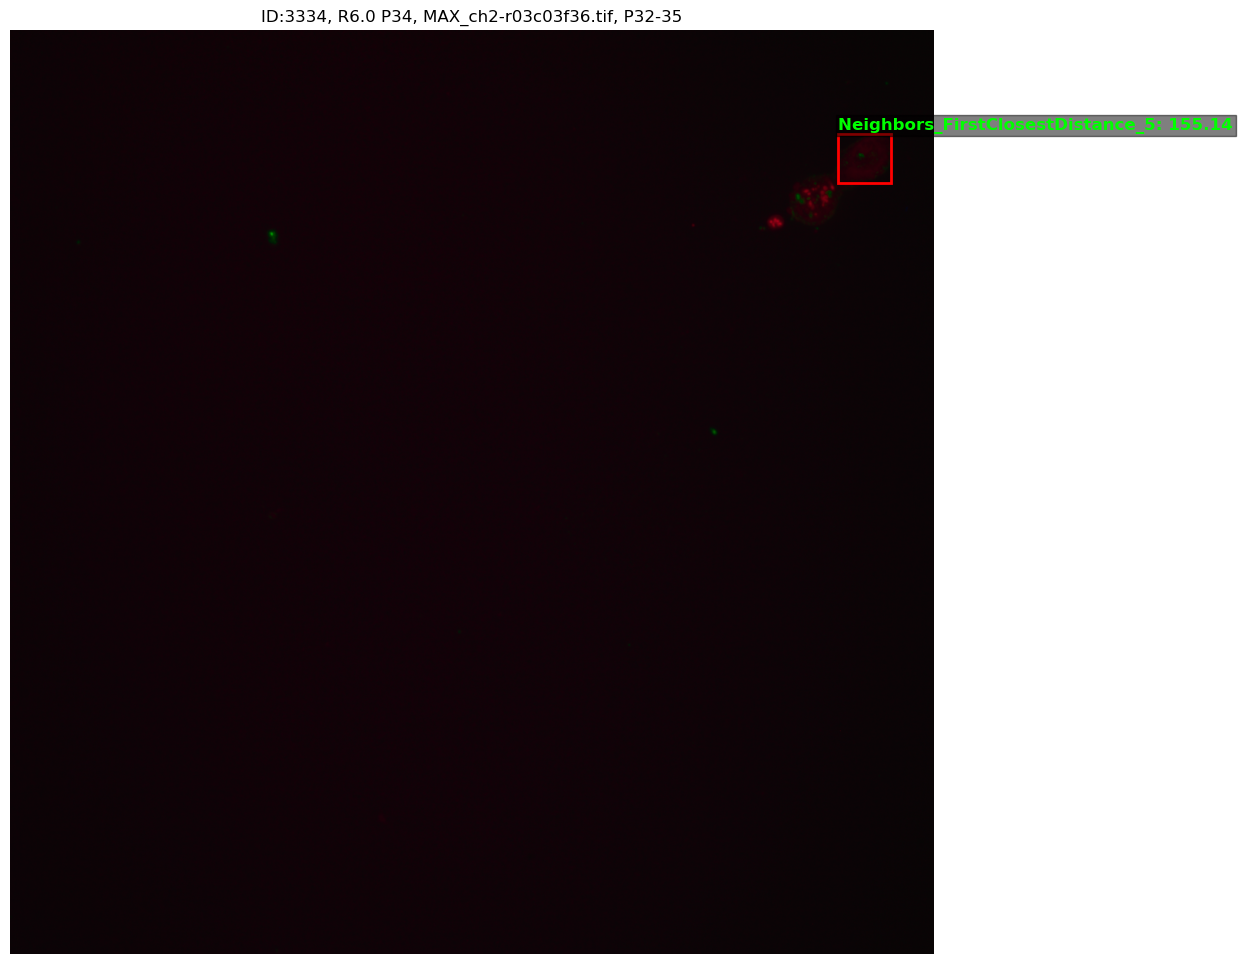

Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch4-r03c03f36.tif
MAX_ch2-r03c03f36.tif
Saved image to: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/Neighbors_FirstClosestDistance_5/3334_R6.0_P34_MAX_MitoTracker-r03c03f36.png


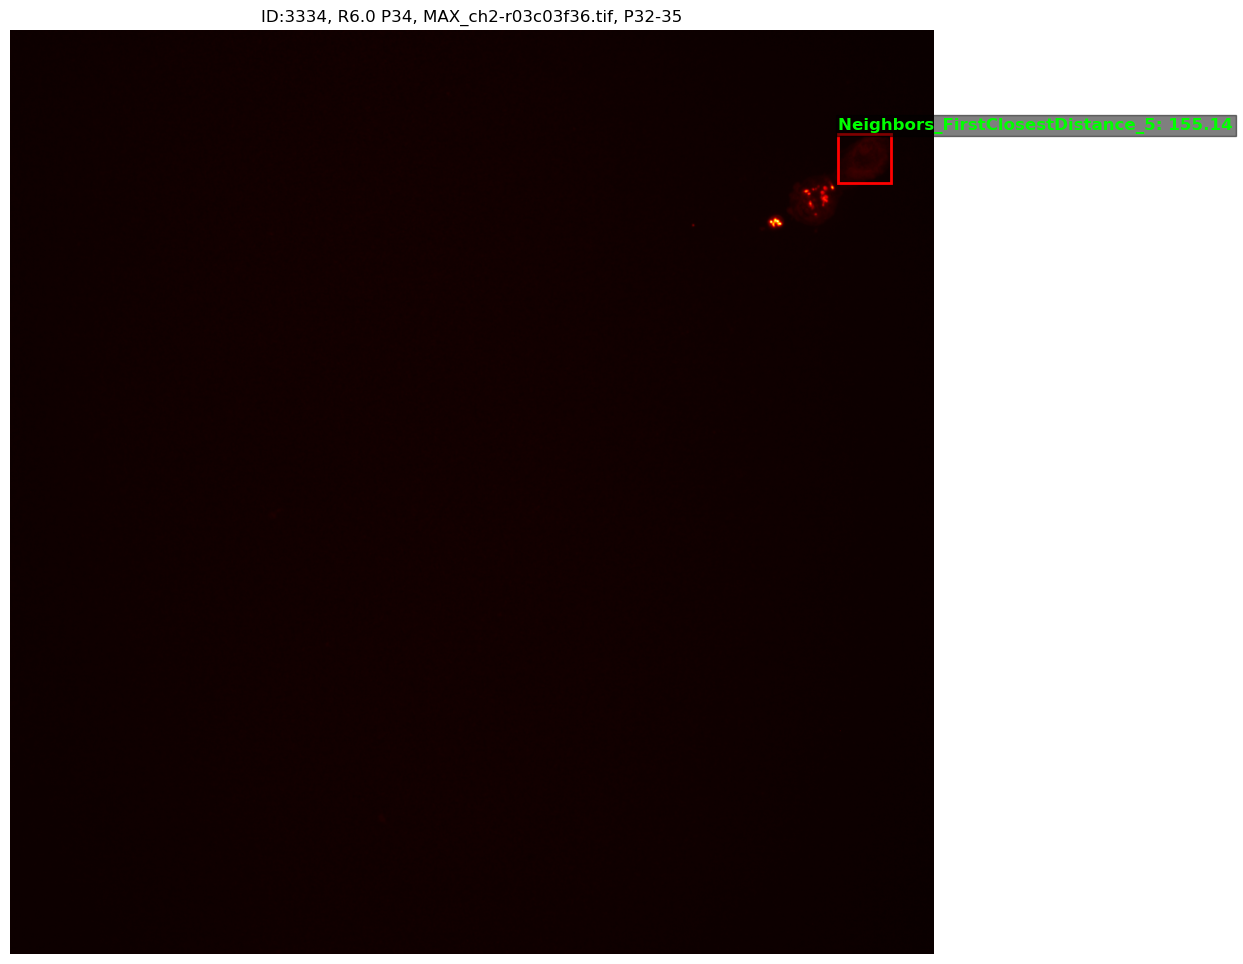

Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch2-r03c03f36.tif
MAX_ch2-r03c03f36_MitoOutlineClosing.png
Saved image to: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/Neighbors_FirstClosestDistance_5/3334_R6.0_P34_MAX_ch2-r03c03f36_MitoOutlineClosing.png


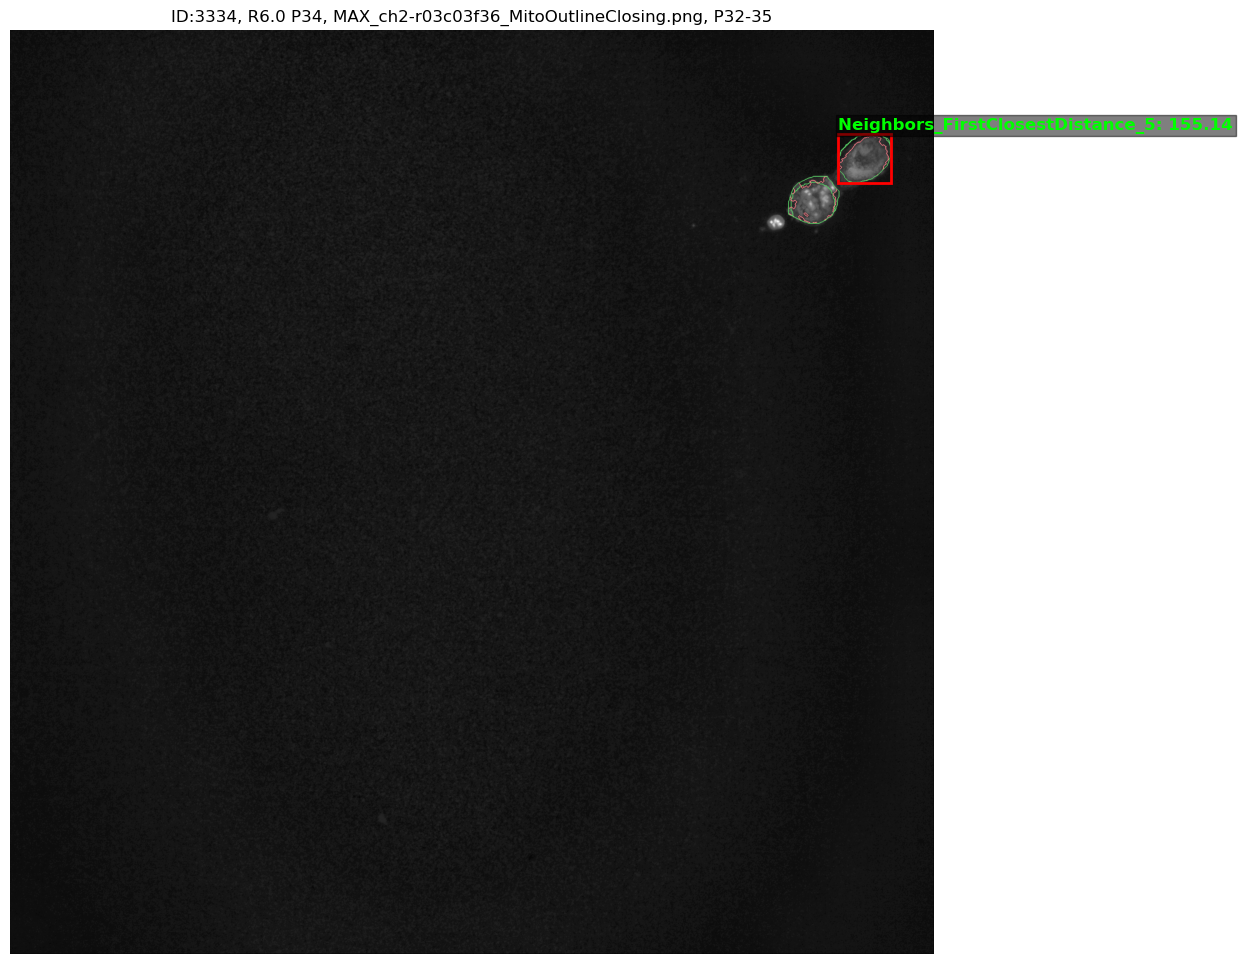

Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/20250410_rep06_output/v4_active/MAX_ch2-r03c03f36_MitoOutlineClosing.png
MAX_ch1-r03c03f36_LysoOutline.png
Saved image to: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/Neighbors_FirstClosestDistance_5/3334_R6.0_P34_MAX_ch1-r03c03f36_LysoOutline.png


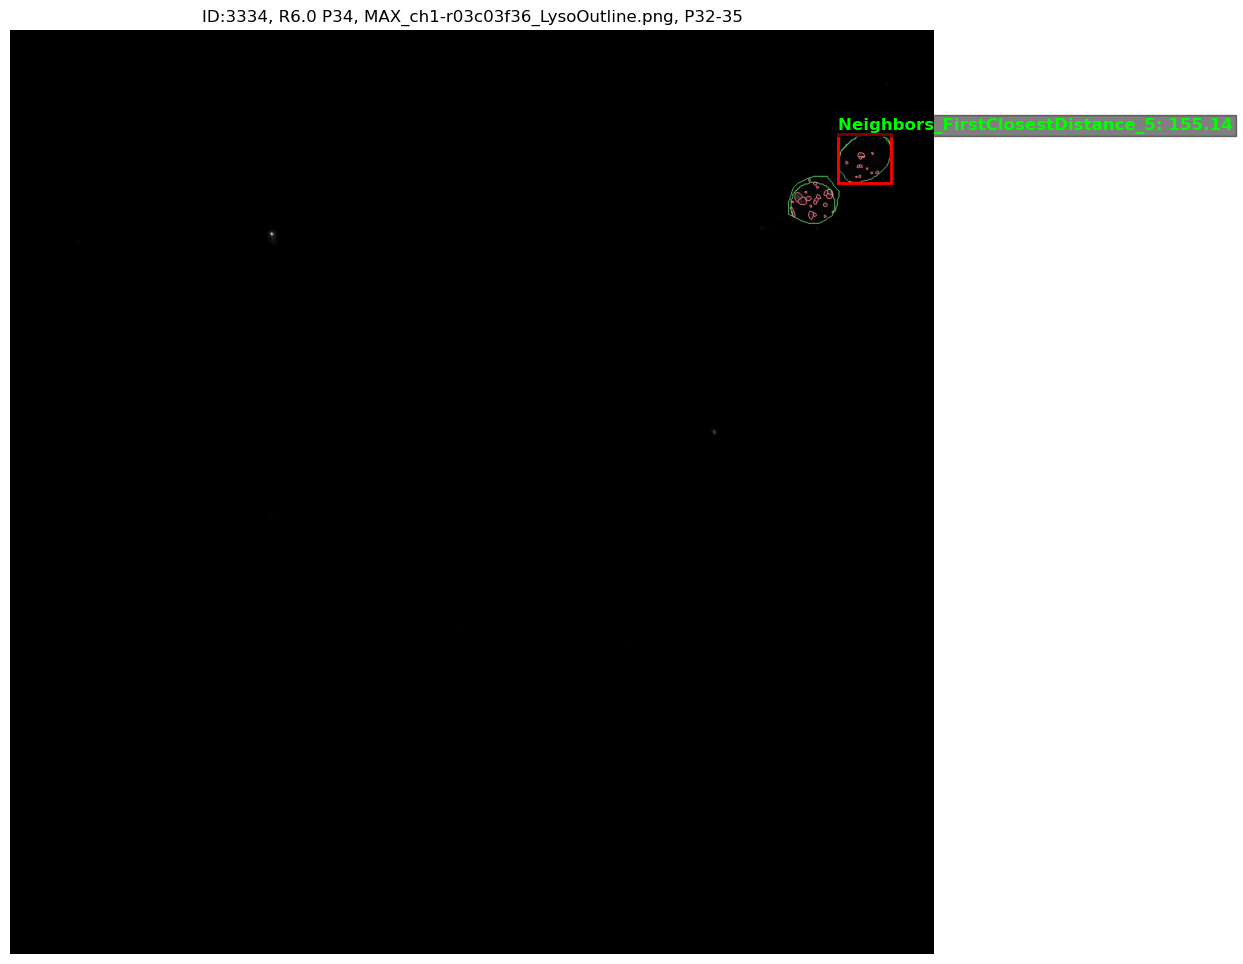

Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/20250410_rep06_output/v4_active/MAX_ch1-r03c03f36_LysoOutline.png


In [153]:
object_key = 3334
savepath = (
    f"/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/{feature_meas}"
    #f"plots/test_manualanalysis/{feature_meas}"
)
os.makedirs(savepath, exist_ok=True)
pull_up_multichannel_image_fromID(
    filtered_df_to_filter,
    object_key=object_key,
    parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/",
    image_channels=["MitoTracker", "LAMP1", "DAPI"],
    feature=feature_meas,
    extension=".tif",
    save=True,
    savepath=savepath,
    show=True,
    # colour_map="Blues_r",
)
pull_up_singlechannel_image_fromID(
    filtered_df_to_filter,
    object_key=object_key,
    parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/",
    image_channel="MitoTracker",
    feature=feature_meas,
    extension=".tif",
    save=True,
    savepath=savepath,
    save_prefix="MitoTracker",
    show=True,
    colour_map="hot",
)
for compartment in ["MitoTracker", "LAMP1"]:
    
        pull_up_cp_segmentation_image_fromID(
            filtered_df_to_filter,
            object_key=object_key,
            parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output",
            image_channel=compartment,
            feature=feature_meas,
            save=True,
            savepath=savepath,
        )

In [154]:
def get_object_keys_from_filenames(path, target_folder_name):
    """Get the unique object keys from the dataframe that match a given filename in a directory"""
    object_keys = []
    for root, dirs, files in os.walk(path):
        for file in files:
            if target_folder_name in root and file.endswith(".png"):
                # Extract the unique object key from the filename
                # Assuming the filename format is something like "R5.0_P11_MAX_ch1-r06c10f21.png_51559.png"
                key_part = file.split("_")[-1].split(".")[
                    0
                ]  # Get the last part before .png
                try:
                    object_key = int(key_part)  # Convert to integer
                    if object_key not in object_keys:  # Avoid duplicates
                        object_keys.append(object_key)
                except ValueError:
                    print(f"Could not convert {key_part} to an integer.")

    return object_keys


keys_to_use = get_object_keys_from_filenames(
    "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/",
    "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/Neighbors_NumberOfNeighbors_5",
)
keys_to_not_use = get_object_keys_from_filenames(
    "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/",
    "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/Neighbors_PercentTouching_5",
)
display(keys_to_use)

[]

In [155]:
# for key in keys_to_use:
#     if key in keys_to_not_use:
#         print(f"Skipping object key {key} as it is in the not use list.")
#         continue
#     object_key = key
#     for feature_meas in [
#         "Neighbors_PercentTouching_5",
#     ]:
#         savepath = f"/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/{feature_meas}"
#         os.makedirs(savepath, exist_ok=True)
#         pull_up_multichannel_image_fromID(
#             filtered_df_to_filter,
#             object_key=object_key,
#             parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/",
#             image_channels=["MitoTracker", "LAMP1", "DAPI"],
#             feature=feature_meas,
#             extension=".tif",
#             save=True,
#             savepath=savepath,
#             show=False,
#             # colour_map="Blues_r",
#         )
#         pull_up_singlechannel_image_fromID(
#             filtered_df_to_filter,
#             object_key=object_key,
#             parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/",
#             image_channel="DAPI",
#             feature=feature_meas,
#             extension=".tif",
#             save=True,
#             savepath=savepath,
#             save_prefix="DAPI",
#             show=False,
#             colour_map="Blues_r",
#         )
#         for compartment in ["MitoTracker", "LAMP1"]:
#             pull_up_cp_segmentation_image_fromID(
#                 filtered_df_to_filter,
#                 object_key=object_key,
#                 parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output",
#                 image_channel=compartment,
#                 feature=feature_meas,
#                 save=True,
#                 savepath=savepath,
#                 show=False,
#             )


## Annotate whole image with values

MAX_ch1-r07c11f40_LysoOutline.png


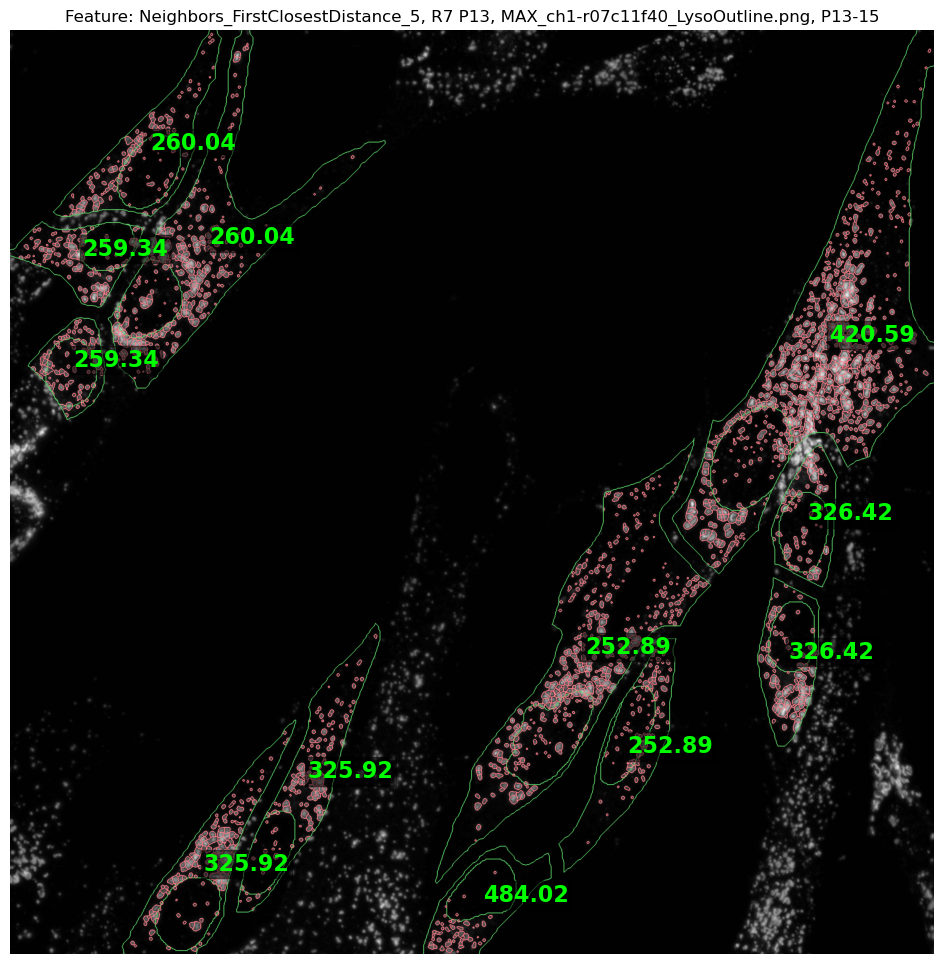

Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/20250501_rep07_output/v5_active/MAX_ch1-r07c11f40_LysoOutline.png


True

In [156]:
img_filename = "MAX_ch1-r07c11f40.tif"
savepath = f"plots/test_manualanalysis/{feature_meas}_annotations"
query_plate_number = 7

os.makedirs(savepath, exist_ok=True)
annotate_cp_segmentation_image_with_feature_values(
    filtered_df_to_filter,
    img_filename=img_filename,
    plate=query_plate_number,
    group=group,
    parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output",
    feature=feature_meas,
    save=True,
    savepath=savepath,
    decimals=2,
)
# check this out https://www.youtube.com/watch?v=TowK3DMUcaE

In [157]:
# Functions to visualize the distributions
# Define and use a simple function to label the plot in axes coordinates
def ridge_label(x, color, label):
    ax = plt.gca()
    ax.text(
        -0.1,
        -0.2,
        label,
        fontweight="bold",
        color=color,
        ha="left",
        va="center",
        transform=ax.transAxes,
    )


def seaborn_ridgeplot(
    df,
    value_col,
    group_col,
    palette=None,
    bw_adjust=1,
    xlabel=None,
    xlim=(None, None),
    title=None,
    fill_alpha=1,
    linewidth=1.5,
    figsize=(20, 30),
    save=True,
    out_dir="",
    show_percentiles=True,
    truncate_outliers=True,
    norm=False,
):
    """
    Make a ridgeline (joyplot) using seaborn FacetGrid and kdeplot
    Args:
        df: DataFrame
        value_col: str, column with numeric values
        group_col: str, column with group/category
        palette: seaborn palette or list/dict of colors
        bw_adjust: float, KDE bandwidth adjust
        xlabel: str or None
        title: str or None
        fill_alpha: float, alpha for fill
        linewidth: float, line width for outline
        figsize: tuple, figure size
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    unique_groups = df[group_col].unique()
    if palette is None:
        palette = sns.cubehelix_palette(len(unique_groups), rot=-0.25, light=0.7)
    else:
        palette = palette

    if truncate_outliers and xlim == (None, None):
        try:
            if norm:
                top_fence = df[value_col].mean() + 10 * df[value_col].std()
                bottom_fence = None  # np.percentile(data_df[y_value], 0.000001)
            else:
                top_fence = np.percentile(df[value_col], 99.9)
                bottom_fence = np.percentile(df[value_col], 0.01)
                # handle errors where the data is very skewed and the percentile is inf or nan
                if top_fence == 0 or np.isnan(top_fence) or np.isinf(top_fence):
                    top_fence = None
                if (
                    bottom_fence == 0
                    or np.isnan(bottom_fence)
                    or np.isinf(bottom_fence)
                ):
                    bottom_fence = None
            xlim = (bottom_fence, top_fence)
        except ValueError as e:
            print(e)
            top_fence = None
            bottom_fence = None
            xlim = (None, None)
        print(f"Truncating outliers at: {xlim}")
        xmin, xmax = xlim
        plot_df = df.copy()
        if xmin is not None:
            plot_df = plot_df[plot_df[value_col] >= xmin]
        if xmax is not None:
            plot_df = plot_df[plot_df[value_col] <= xmax]
    else:
        plot_df = df.copy()
    # Initialize the FacetGrid object
    g = sns.FacetGrid(
        plot_df,
        row=group_col,
        hue=group_col,
        aspect=15,
        height=0.5,
        palette=palette,
        xlim=xlim,
    )
    # Draw the densities in a few steps
    g.map(
        sns.kdeplot,
        value_col,
        bw_adjust=bw_adjust,
        clip_on=False,
        fill=True,
        alpha=fill_alpha,
        linewidth=linewidth,
    )
    g.map(sns.kdeplot, value_col, clip_on=False, color="w", lw=2, bw_adjust=bw_adjust)

    if show_percentiles:
        percentiles = [5, 12.5, 25, 50, 75, 87.5, 95]
        for ax in g.axes.flatten():
            # group label text (FacetGrid puts "group_col = <value>" in the title)
            title_text = ax.get_title()
            if " = " in title_text:
                group_val = title_text.split(" = ", 1)[1]
            else:
                group_val = title_text

            group_data = df[df[group_col] == group_val][value_col].dropna()
            if group_data.empty:
                continue

            # pick the most representative line on the axis (the KDE line)
            lines = ax.get_lines()
            if not lines:
                continue
            # choose the line with the largest x-range (robust against multiple lines)
            kde_line = max(lines, key=lambda l: np.ptp(l.get_xdata()))
            xs = kde_line.get_xdata()
            ys = kde_line.get_ydata()
            # line_colour = kde_line.get
            # compute median and interpolate its KDE height
            median = np.median(group_data)
            height = np.interp(median, xs, ys, left=0.0, right=0.0)

            # draw a solid thicker median line from y=0 up to the KDE height
            ax.vlines(
                median, 0, height, color="black", linewidth=3, linestyle=":", zorder=4
            )
            ax.set_xlim(xlim)
            # draw lighter dashed lines for the percentiles (optional)
            group_percentiles = np.percentile(group_data, percentiles)
            for p in group_percentiles:
                ax.vlines(p, 0, height, color="dimgray", ls=":", alpha=0.6, linewidth=2)
    # passing color=None to refline() uses the hue mapping
    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

    g.map(ridge_label, value_col)

    # Set the subplots to overlap
    g.figure.subplots_adjust(hspace=-0.25)
    g.figure.set_size_inches(figsize)
    # Remove axes details that don't play well with overlap
    g.set_titles("")
    g.set(yticks=[], ylabel="", xlim=xlim)
    g.despine(bottom=True, left=True)
    if xlabel:
        plt.xlabel(xlabel, fontweight="bold", fontsize=14)
    else:
        plt.xlabel(value_col, fontweight="bold", fontsize=14)
    if title:
        g.figure.suptitle(title, ha="right", fontsize=18, fontweight="bold")
    plt.xlim(xlim)
    plt.tight_layout()
    if save:
        plt.savefig(f"{Path(out_dir, f'{value_col}_{group_col}_joyplot')}.png")
    plt.show()


def plotly_histogram(df, y_value, group_var, save=False, out_dir=""):
    import kaleido

    df_sorted = df.sort_values(
        by=[group_var], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    hist2 = px.histogram(
        df_sorted,
        x=y_value,
        color=group_var,
        marginal="box",
        # histnorm='probability density',
        # range_x=(0, top_fence),
    )
    hist2.write_image(Path(out_dir, f"{y_value}_histogram.png"), scale=1.5)
    hist2.show()


## Summary Stats

In [158]:
summary_outpath = "postprocessed_summary_stats"
os.makedirs(summary_outpath, exist_ok=True)

feature_cols = [
    "AreaShape_Area",
    "Nuclei_AreaShape_Area",
    "Cell_Nuclei_Area_Ratio",
    "Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized",
    "Intensity_MeanIntensity_LAMP1_MAX_WellNormalized",
    "Intensity_MeanIntensity_MitoTracker_MAX_WellNormalized",
    "Neighbors_NumberOfNeighbors_5",
    "Neighbors_PercentTouching_5",
    "Nuclei_Neighbors_NumberOfNeighbors_1",
    "Nuclei_Neighbors_PercentTouching_1",
    "Children_Lysosomes_Count",
    "Children_Mitochondria_Count",
]
include_cols = ["Number_Object_Number"] + feature_cols
print(include_cols)


def make_summary_stats_for_df_and_feature(
    df,
    x_value,
    feature,
    summary_outpath,
    df_tag="original",
    plate_col_name="Plate_Number",
    feature_name="area",
    group_name="passage_group",
    include_cols=[],
    inculded_percentiles=[
        0.01,
        0.025,
        0.05,
        0.1,
        0.25,
        0.5,
        0.75,
        0.9,
        0.95,
        0.975,
        0.99,
    ],
):
    from pathlib import Path

    try:
        table_csvname = f"{df_tag}_total_combined_stats.csv"
        feature_csvname = f"{df_tag}_{feature_name}_by_{group_name}_stats.csv"
        agg_feature_csvname = f"{df_tag}_agg_{feature_name}_by_{group_name}_stats.csv"

        subfolder_name = f"{df_tag}_{feature_name}_summary_stats"
        parent_folder = Path(summary_outpath, subfolder_name)
        parent_folder.mkdir(exist_ok=True)

        if not include_cols:
            df_to_summarize = df
        else:
            df_to_summarize = df[include_cols]
        df_to_summarize.describe(percentiles=inculded_percentiles).to_csv(
            os.path.join(summary_outpath, table_csvname)
        )
        group_averages = df.groupby(
            [x_value, plate_col_name], as_index=False, observed=True
        )[feature]
        # Reset the index to get a clean DataFrame
        # average_df = group_averages.reset_index()
        avg_summary = group_averages.describe(percentiles=inculded_percentiles)
        avg_summary_sorted = avg_summary.sort_values(
            by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
        ).reset_index(drop=True)
        avg_summary_sorted.to_csv(
            os.path.join(summary_outpath, subfolder_name, feature_csvname)
        )

        # do the agg by passage group only
        group_averages_agg = df.groupby([x_value], as_index=False, observed=True)[
            feature
        ]
        avg_agg_summary = group_averages_agg.describe(percentiles=inculded_percentiles)
        avg_agg_summary_sorted = avg_agg_summary.sort_values(
            by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
        ).reset_index(drop=True)
        avg_agg_summary_sorted.T.to_csv(
            os.path.join(summary_outpath, subfolder_name, agg_feature_csvname)
        )
        print(
            f"saved files {(table_csvname, feature_csvname, agg_feature_csvname)} to {summary_outpath}"
        )
        return True
    except ValueError as e:
        print(f"Could not make summary stats: {e}")
        return False


this_df = combined_cell_df_mitolyso #extrafeatures_filtered_cell_df_mitolyso.copy()


for feature in feature_cols:
    df_sorted = this_df.sort_values(
        by=["AllGroups"], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    make_summary_stats_for_df_and_feature(
        df_sorted,
        "AllGroups",
        feature,
        summary_outpath,
        df_tag="original",
        feature_name=feature,
        include_cols=include_cols,
    )
    # seaborn_ridgeplot(
    #     df_sorted,
    #     value_col=feature,
    #     group_col="AllGroups",
    #     palette="Set2",
    #     save=True,
    #     out_dir=summary_outpath,
    #     show_percentiles=True,
    #     truncate_outliers=True,
    # )


['Number_Object_Number', 'AreaShape_Area', 'Nuclei_AreaShape_Area', 'Cell_Nuclei_Area_Ratio', 'Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized', 'Intensity_MeanIntensity_LAMP1_MAX_WellNormalized', 'Intensity_MeanIntensity_MitoTracker_MAX_WellNormalized', 'Neighbors_NumberOfNeighbors_5', 'Neighbors_PercentTouching_5', 'Nuclei_Neighbors_NumberOfNeighbors_1', 'Nuclei_Neighbors_PercentTouching_1', 'Children_Lysosomes_Count', 'Children_Mitochondria_Count']
saved files ('original_total_combined_stats.csv', 'original_AreaShape_Area_by_passage_group_stats.csv', 'original_agg_AreaShape_Area_by_passage_group_stats.csv') to postprocessed_summary_stats
saved files ('original_total_combined_stats.csv', 'original_Nuclei_AreaShape_Area_by_passage_group_stats.csv', 'original_agg_Nuclei_AreaShape_Area_by_passage_group_stats.csv') to postprocessed_summary_stats
saved files ('original_total_combined_stats.csv', 'original_Cell_Nuclei_Area_Ratio_by_passage_group_stats.csv', 'original_agg_Cell_Nucl